# Harbor Tasks Analysis

Analysis of task complexity distribution and category diversity across all dataset versions in `harbor_tasks_8192_deduped/`.

In [46]:
import re
import tomllib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.dpi'] = 300 
plt.style.use('seaborn-v0_8-whitegrid')

In [47]:
TASKS_DIR = Path('../data')

# Dataset version directories (task dirs live directly inside these)
DATASET_DIRS = [
    TASKS_DIR / 'harbor_4.5opus_tasks' / 'harbor_tasks_claude4.5_opus' / 'harbor_tasks_part2_2-1',
    TASKS_DIR / 'harbor_4.5opus_tasks' / 'harbor_tasks_claude4.5_opus' / 'harbor_tasks_part2_2-2',
    TASKS_DIR / 'harbor_4.5opus_tasks' / 'harbor_tasks_claude4.5_opus' / 'harbor_tasks_part2_2-3',
    TASKS_DIR / 'harbor_4.5opus_tasks' / 'harbor_tasks_claude4.5_opus' / 'harbor_tasks_part2_2-4',
    TASKS_DIR / 'harbor_tasks_8192_deduped',
    TASKS_DIR / 'harbor_4.8opus_tasks_v3_internet_access_config',
]

## 1. Load Task Data

In [48]:
_STOPWORDS = {'the', 'and', 'for', 'that', 'with', 'this', 'from', 'are', 'have',
              'been', 'will', 'your', 'you', 'has', 'was', 'not', 'all', 'its',
              'can', 'but', 'which', 'any', 'also', 'should', 'into', 'now'}

_OUTCOME_PAT = re.compile(
    r'\bassert\b[^\n]*(subprocess|returncode|stdout|stderr|capture_output|\.read\b|content)',
    re.IGNORECASE,
)
_ASSERT_PAT = re.compile(r'\bassert\b')
_TOKEN_PAT   = re.compile(r'\b[a-zA-Z_][a-zA-Z0-9_]{2,}\b')

def compute_structural_score(test_code):
    """Fraction of assert lines that check outcomes (process/stdout/content) vs. state."""
    total = len(_ASSERT_PAT.findall(test_code))
    if not total:
        return 0.0
    outcome = len(_OUTCOME_PAT.findall(test_code))
    return outcome / total

def compute_desc_overlap(description, test_code):
    """Fraction of assert lines containing at least one keyword from the task description."""
    desc_kw = {t for t in _TOKEN_PAT.findall(description.lower()) if t not in _STOPWORDS}
    if not desc_kw:
        return 0.0
    assert_lines = re.findall(r'\bassert\b[^\n]*', test_code)
    if not assert_lines:
        return 0.0
    overlapping = sum(
        1 for ln in assert_lines
        if {t for t in _TOKEN_PAT.findall(ln.lower()) if t not in _STOPWORDS} & desc_kw
    )
    return overlapping / len(assert_lines)

In [66]:
VERSION_LABELS = {
    'harbor_4.5opus_tasks':              'V1',
    'harbor_tasks_8192_deduped':         'V2',
    'harbor_4.8opus_tasks_v3_internet_access_config': 'V3',
}

def get_version_label(dataset_dir):
    for key, label in VERSION_LABELS.items():
        if key in str(dataset_dir):
            return label
    return 'unknown'

def load_tasks(dataset_dirs, max_per_dir=None):
    if isinstance(dataset_dirs, (str, Path)):
        dataset_dirs = [dataset_dirs]
    rows = []
    seen = set()
    for dataset_dir in dataset_dirs:
        if not dataset_dir.exists():
            continue
        version = get_version_label(dataset_dir)
        count = 0
        for task_dir in sorted(dataset_dir.iterdir()):
            if not task_dir.is_dir() or not task_dir.name.startswith('task_'):
                continue
            if task_dir.name in seen:
                continue
            seen.add(task_dir.name)

            toml_path = task_dir / 'task.toml'
            instruction_path = task_dir / 'instruction.md'
            test_path = task_dir / 'tests' / 'test_final_state.py'

            if not toml_path.exists() or not instruction_path.exists():
                continue

            with open(toml_path, 'rb') as f:
                meta = tomllib.load(f).get('metadata', {})

            description = instruction_path.read_text(errors='replace')
            test_code = test_path.read_text(errors='replace') if test_path.exists() else ''

            rows.append({
                'task_id':          task_dir.name,
                'version':          version,
                'difficulty':       meta.get('difficulty', 'unknown'),
                'category':         meta.get('category', 'unknown').lower().strip(),
                'description_len':  len(description),
                'num_test_funcs':   len(re.findall(r'def test_', test_code)),
                'num_asserts':      len(_ASSERT_PAT.findall(test_code)),
                'structural_score': compute_structural_score(test_code),
                'desc_overlap':     compute_desc_overlap(description, test_code),
            })
            count += 1
            if max_per_dir and count >= max_per_dir:
                break
    return pd.DataFrame(rows)

# Sample up to 500 tasks per directory for fast loading (~10s total)
df = load_tasks(DATASET_DIRS) #max_per_dir=500)
print(f'Loaded {len(df):,} tasks')
print(df['difficulty'].value_counts().to_string())

Loaded 18,185 tasks
difficulty
medium    11455
easy       3370
hard       3360


In [83]:
df.version.unique()

<ArrowStringArray>
['V1', 'V2', 'V3']
Length: 3, dtype: str

In [69]:
version_tag = df.version.unique()[0] if len(df.version.unique()) == 1 else '-'.join(list(df.version.unique()))
print(f'veresion tag is {version_tag}')

veresion tag is V1-V2-V3


## 2. Task Complexity Metrics Distribution

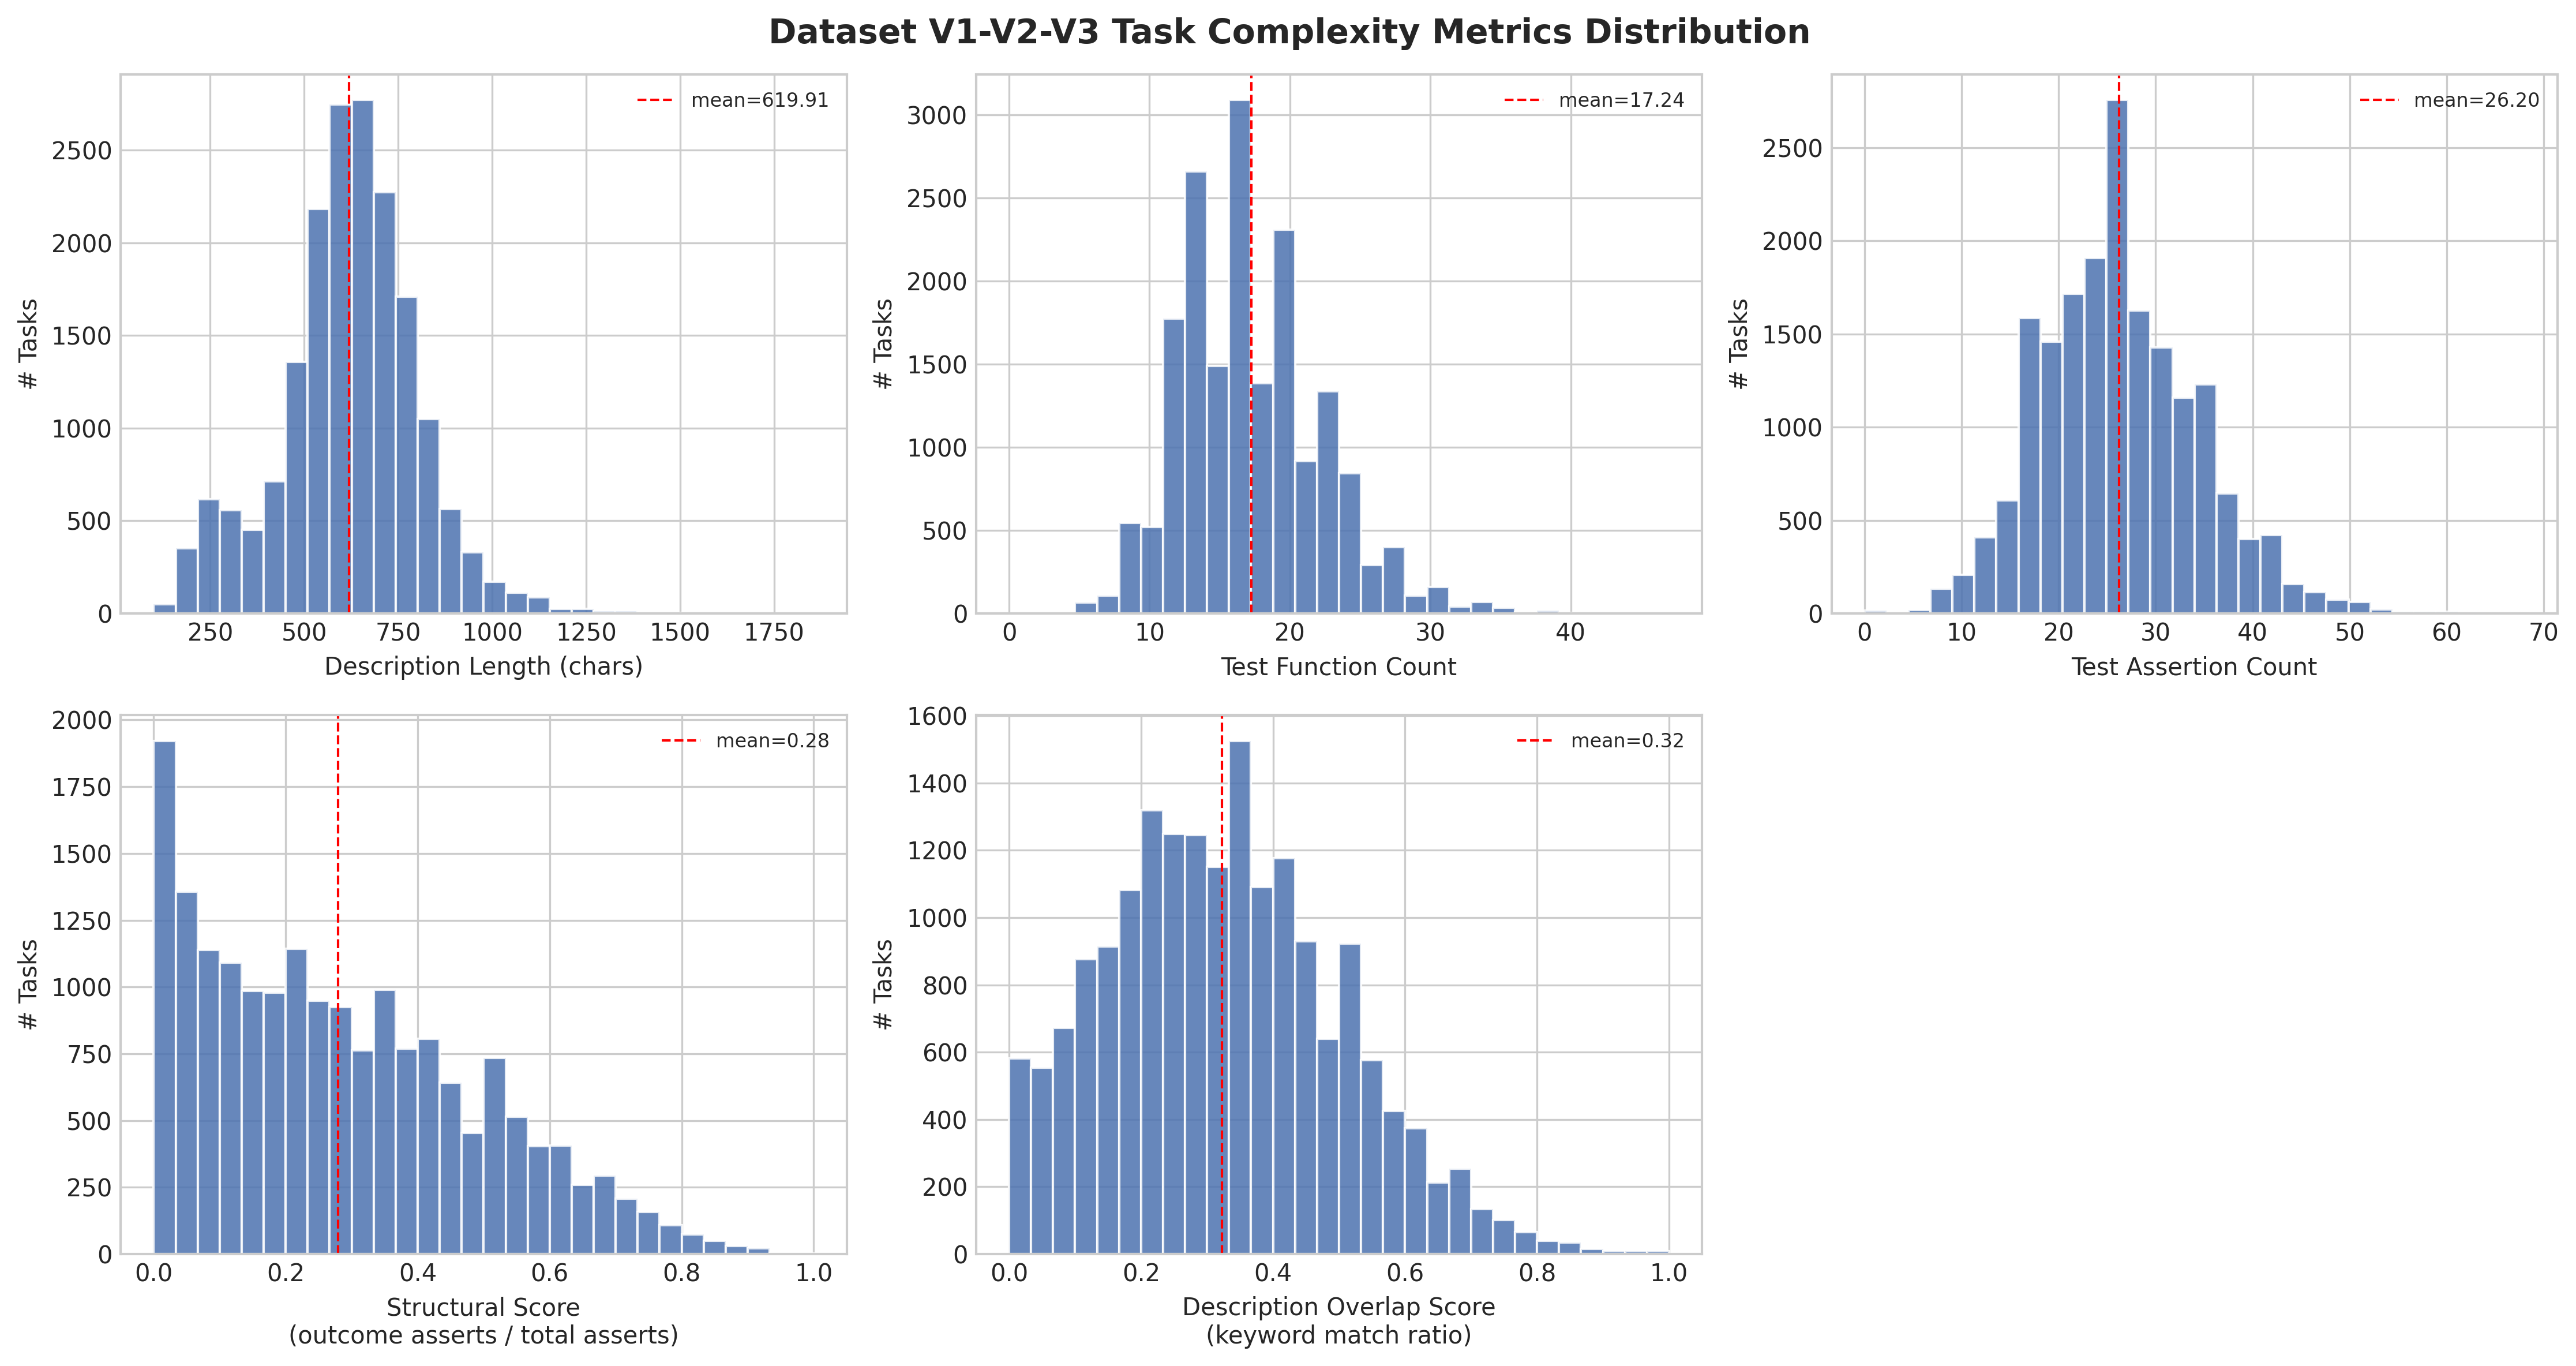

       description_len  num_test_funcs  num_asserts  structural_score  desc_overlap
count        18185.000       18185.000    18185.000         18185.000     18185.000
mean           619.914          17.238       26.205             0.279         0.323
std            183.281           5.054        8.075             0.209         0.176
min            100.000           0.000        0.000             0.000         0.000
25%            523.000          14.000       21.000             0.103         0.190
50%            628.000          17.000       26.000             0.250         0.312
75%            731.000          20.000       31.000             0.423         0.440
max           1855.000          47.000       68.000             1.000         1.000


In [70]:
metrics = [
    ('description_len',  'Description Length (chars)'),
    ('num_test_funcs',   'Test Function Count'),
    ('num_asserts',      'Test Assertion Count'),
    ('structural_score', 'Structural Score\n(outcome asserts / total asserts)'),
    ('desc_overlap',     'Description Overlap Score\n(keyword match ratio)'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f'Dataset {version_tag} Task Complexity Metrics Distribution', fontsize=14, fontweight='bold')

for ax, (col, label) in zip(axes.flat, metrics):
    ax.hist(df[col], bins=30, color='#4C72B0', edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1,
               label=f'mean={df[col].mean():.2f}')
    ax.set_xlabel(label)
    ax.set_ylabel('# Tasks')
    ax.legend(fontsize=8)

# Hide unused subplot
axes.flat[-1].set_visible(False)

fig.savefig(f'{version_tag}_task_complexity_metrics_dist.pdf')
plt.tight_layout()
plt.show()

print(df[['description_len', 'num_test_funcs', 'num_asserts', 'structural_score', 'desc_overlap']]
      .describe().round(3).to_string())

## 3. Task Categories (multi-label)

In [72]:
CATEGORY_TO_DOMAIN = {
    # file operations
    'file and directory management':         'file_operations',
    'symbolic link management':              'file_operations',
    'file permissions and ownership':        'file_operations',
    'complex permissions management':        'file_operations',
    'archive and compression':               'file_operations',
    'backup and archiving':                  'file_operations',
    'file compression and extraction':       'file_operations',
    'corrupt archive recovery':              'file_operations',
    'file search and grep':                  'file_operations',
    'text processing and manipulation':      'file_operations',
    'text processing':                       'file_operations',
    'log analysis':                          'file_operations',
    'log parsing and analysis':              'file_operations',
    'regex-based log filtering':             'file_operations',
    'awk and sed text processing':           'file_operations',
    'cut and paste column manipulation':     'file_operations',
    'sort and uniq frequency counting':      'file_operations',
    'find and xargs batch file operations':  'file_operations',
    'text diffing and patch application':    'file_operations',
    'text encoding conversions':             'file_operations',
    'checksum verification':                 'file_operations',
    'binary data format parsing':            'file_operations',
    # system administration
    'dev environment setup':                 'system_administration',
    'running old code':                      'system_administration',
    'launch a webserver':                    'system_administration',
    'firewall configuration':                'system_administration',
    'cron job management':                   'system_administration',
    'cron and systemd timer authoring (user)': 'system_administration',
    'scheduled tasks and cron jobs':         'system_administration',
    'process management':                    'system_administration',
    'service management':                    'system_administration',
    'service configuration':                 'system_administration',
    'network configuration':                 'system_administration',
    'network diagnostics':                   'system_administration',
    'dns and hostname resolution':           'system_administration',
    'user and group management':             'system_administration',
    'user and permission management':        'system_administration',
    'disk and storage management':           'system_administration',
    'disk usage analysis':                   'system_administration',
    'environment variables and shell config': 'system_administration',
    'environment variable and dotenv management': 'system_administration',
    'environment configuration':             'system_administration',
    'package management':                    'system_administration',
    'pip package environment management':    'system_administration',
    'python virtual environment setup with venv': 'system_administration',
    'ssh configuration':                     'system_administration',
    'ssh keypair generation and management': 'system_administration',
    'docker container management':           'system_administration',
    'container management':                  'system_administration',
    'time zone and locale configuration':    'system_administration',
    'system monitoring and diagnostics':     'system_administration',
    'shell scripting automation':            'system_administration',
    # software engineering
    'makefile authoring and task automation': 'software_engineering',
    'semantic version bumping and changelogs': 'software_engineering',
    'git operations':                        'software_engineering',
    'git repository operations':             'software_engineering',
    'git submodule management':              'software_engineering',
    'ci/cd pipeline configuration':          'software_engineering',
    'api design and implementation':         'software_engineering',
    'api testing and curl operations':       'software_engineering',
    'headless browser data scraping':        'software_engineering',
    'refactoring':                           'software_engineering',
    'testing and tdd':                       'software_engineering',
    'dependency management':                 'software_engineering',
    'build systems':                         'software_engineering',
    'code generation':                       'software_engineering',
    'markdown documentation generation and linting': 'software_engineering',
    'remote file synchronization':           'software_engineering',
    # debugging
    'debugging':                             'debugging',
    'error diagnosis and fixing':            'debugging',
    'performance optimization':              'debugging',
    'memory and resource profiling':         'debugging',
    'distributed system debugging':          'debugging',
    'stripped elf binary reverse engineering': 'debugging',
    # data processing
    'data pipeline with error recovery':     'data_processing',
    'data transformation':                   'data_processing',
    'etl pipeline':                          'data_processing',
    'csv and tsv processing':                'data_processing',
    'csv/json data manipulation':            'data_processing',
    'json and yaml manipulation':            'data_processing',
    'json schema validation and jq processing': 'data_processing',
    'yaml and toml configuration editing':   'data_processing',
    'ini configuration parsing':             'data_processing',
    'xml processing':                        'data_processing',
    # data querying
    'sqlite database operations via cli':    'data_querying',
    'database operations':                   'data_querying',
    'database administration':               'data_querying',
    'database migration with data validation': 'data_querying',
    'sql query writing':                     'data_querying',
    # security
    'cryptography and certificates':         'security',
    'certificate management':                'security',
    'gpg file encryption and signature verification': 'security',
    'security hardening':                    'security',
    'security scanning':                     'security',
    'authentication configuration':          'security',
    'exploiting/fixing security vulnerabilities': 'security',
    # scientific computing
    'numerical computing':                   'scientific_computing',
    'simulation':                            'scientific_computing',
    'optimization solvers':                  'scientific_computing',
    'data analysis and visualization':       'scientific_computing',
    'machine learning pipeline':             'scientific_computing',
    'statistical analysis':                  'scientific_computing',
}

df['domain'] = df['category'].map(CATEGORY_TO_DOMAIN).fillna('other')

unmapped = df[df['domain'] == 'other']['category'].value_counts()
if len(unmapped) > 0:
    print('Categories mapped to "other" (check if any need explicit mapping):')
    print(unmapped.to_string())
else:
    print('All categories mapped successfully.')

All categories mapped successfully.


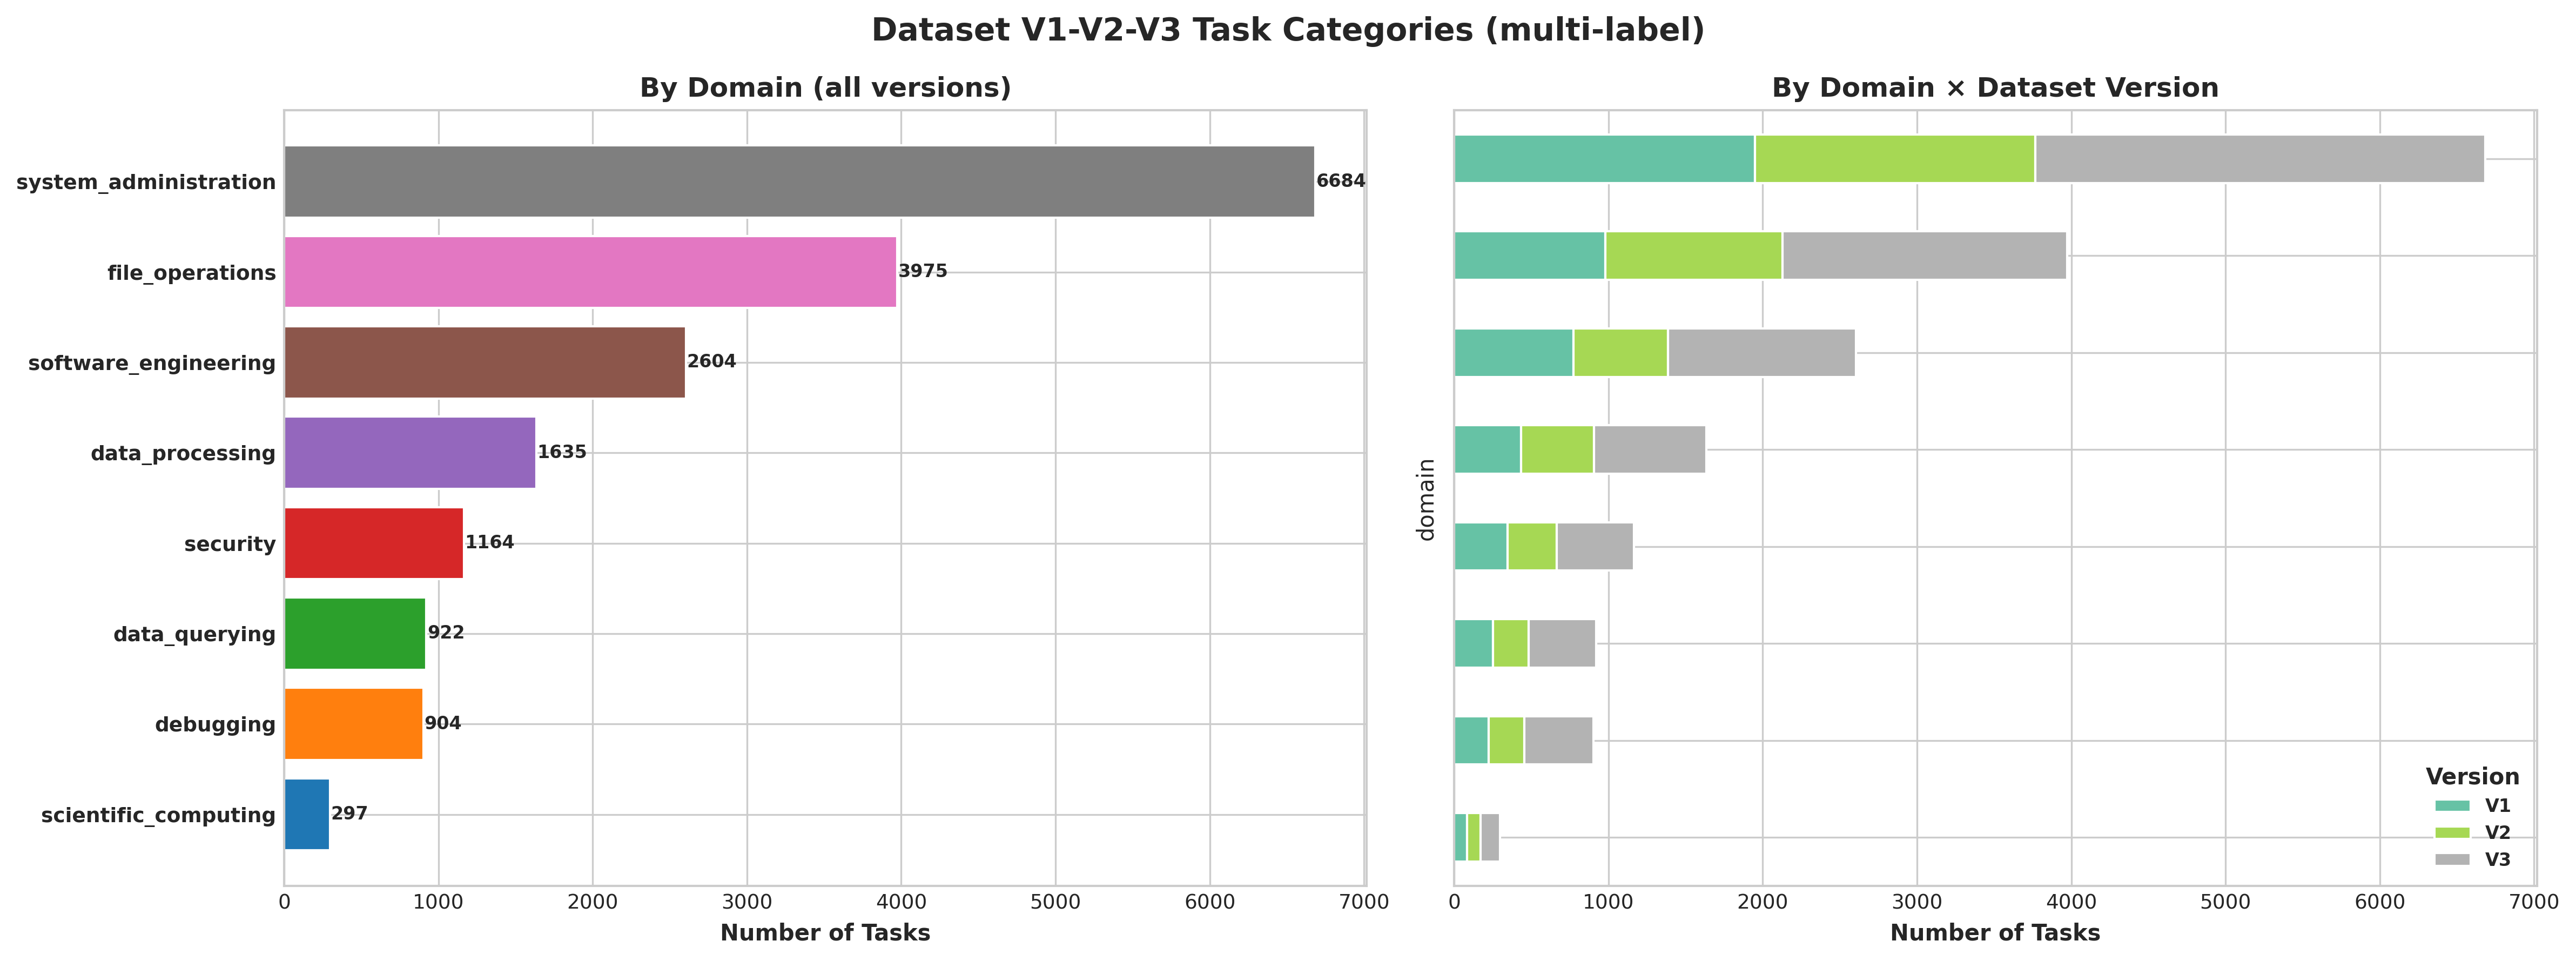


Total tasks: 18,185
Unique domains: 8
Unique categories: 64


In [84]:
domain_counts = df['domain'].value_counts().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Dataset {version_tag} Task Categories (multi-label)', fontsize=14, fontweight='bold')

# Left: domain-level bar chart
colors = plt.cm.tab10.colors
axes[0].barh(domain_counts.index, domain_counts.values, color=colors[:len(domain_counts)], edgecolor='white')
axes[0].set_xlabel('Number of Tasks', fontweight='bold')
axes[0].set_title('By Domain (all versions)', fontweight='bold')
axes[0].tick_params(axis='both', labelsize=9)
for label in axes[0].get_yticklabels():
    label.set_fontweight('bold')
for i, v in enumerate(domain_counts.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=8, fontweight='bold')

# Right: stacked bar by dataset version (y labels same as left, hide them)
pivot = df.pivot_table(index='domain', columns='version', aggfunc='size', fill_value=0)
pivot = pivot.reindex(domain_counts.index)
pivot.plot(kind='barh', stacked=True, ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_xlabel('Number of Tasks', fontweight='bold')
axes[1].set_title('By Domain × Dataset Version', fontweight='bold')
axes[1].set_yticklabels([])
axes[1].tick_params(axis='x', labelsize=9)
legend = axes[1].legend(title='Version', fontsize=8)
legend.get_title().set_fontweight('bold')
for text in legend.get_texts():
    text.set_fontweight('bold')

fig.savefig(f'{version_tag}_task_categories_multi-label.pdf')
plt.tight_layout()
plt.show()

print(f'\nTotal tasks: {len(df):,}')
print(f'Unique domains: {df["domain"].nunique()}')
print(f'Unique categories: {df["category"].nunique()}')

#### All Dataset versions 

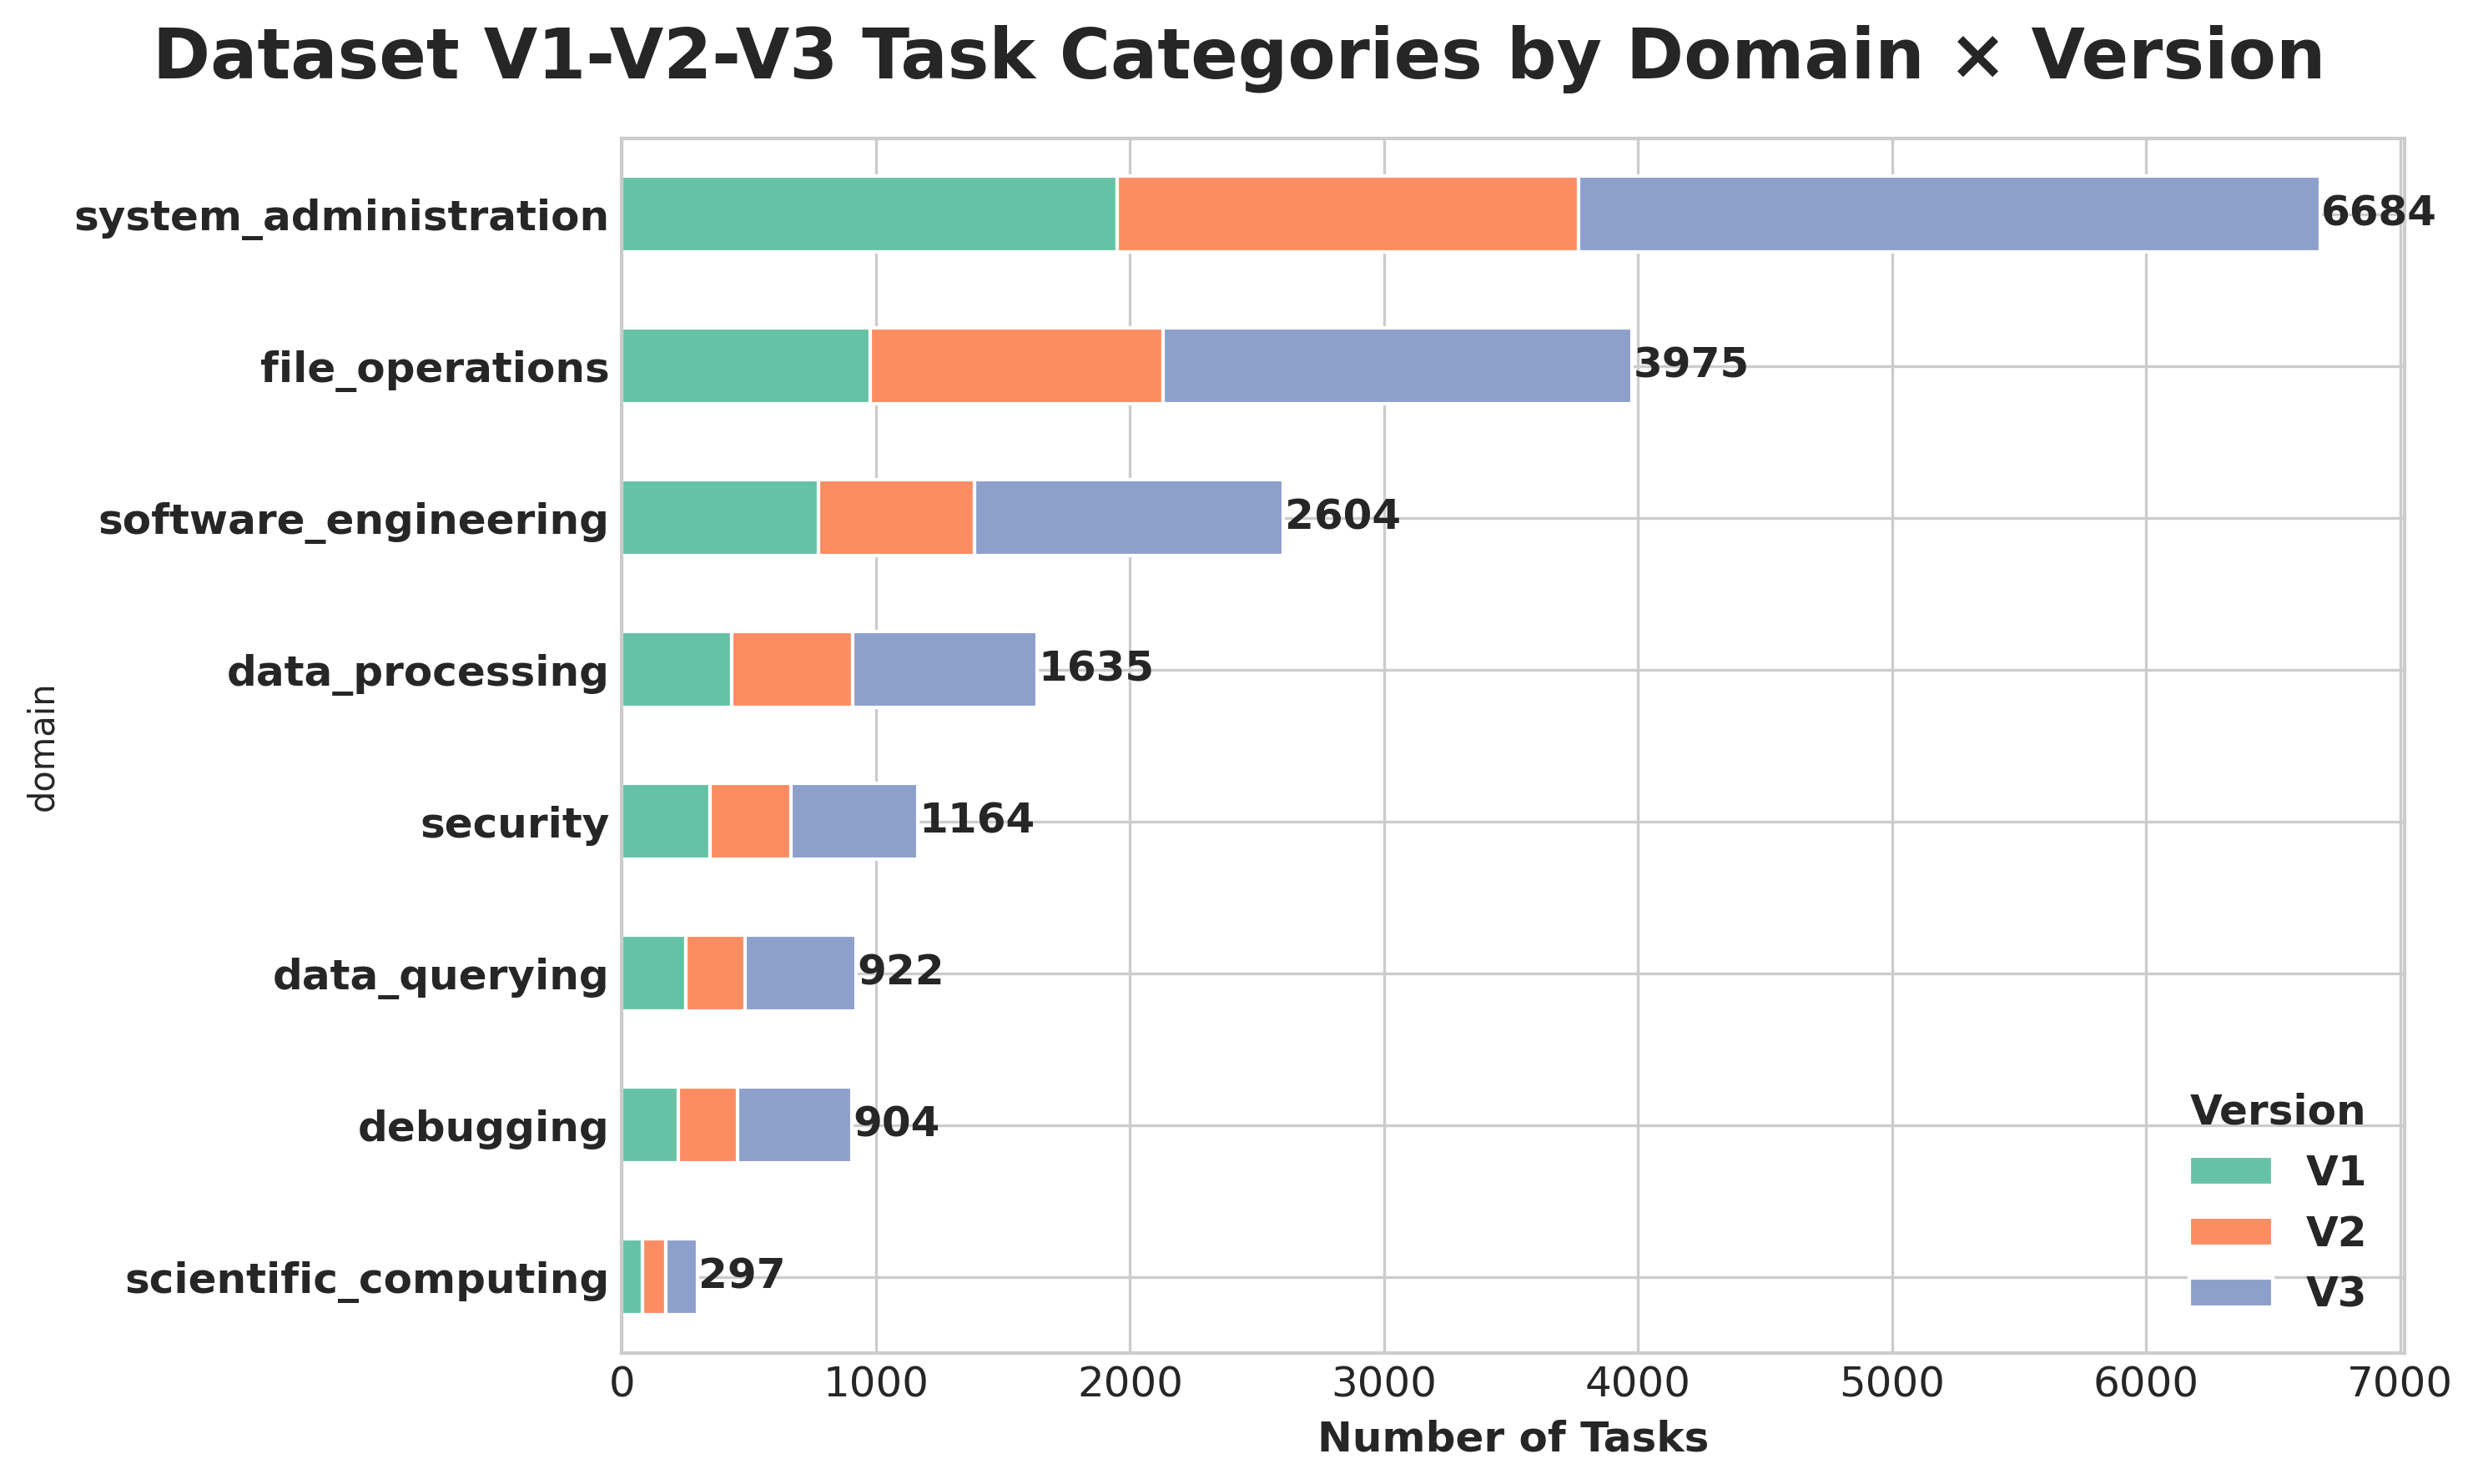

In [100]:
set2 = plt.cm.Set2.colors
version_order = ['V1', 'V2', 'V3']
colors_set2 = {v: set2[i] for i, v in enumerate(version_order)}

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(f'Dataset {version_tag} Task Categories by Domain × Version', fontsize=20, fontweight='bold')

pivot = df.pivot_table(index='domain', columns='version', aggfunc='size', fill_value=0)
pivot = pivot.reindex(domain_counts.index)
# Reorder columns to match version_order so colors align with char count graph
pivot = pivot[[v for v in version_order if v in pivot.columns]]

pivot.plot(kind='barh', stacked=True, ax=ax,
           color=[colors_set2[v] for v in pivot.columns], edgecolor='white')

ax.set_xlabel('Number of Tasks', fontsize=12, fontweight='bold')
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(12)
ax.tick_params(axis='x', labelsize=12)

# Annotate total at end of each bar
totals = pivot.sum(axis=1)
for i, (idx, total) in enumerate(totals.items()):
    ax.text(total + 5, i, str(total), va='center', fontsize=12, fontweight='bold')

legend = ax.legend(title='Version', fontsize=12)
legend.get_title().set_fontweight('bold')
legend.get_title().set_fontsize(12)
for text in legend.get_texts():
    text.set_fontweight('bold')
    text.set_fontsize(12)

plt.tight_layout()
fig.savefig(f'{version_tag}_domain_by_version.pdf')
plt.show()

#### Single Categories

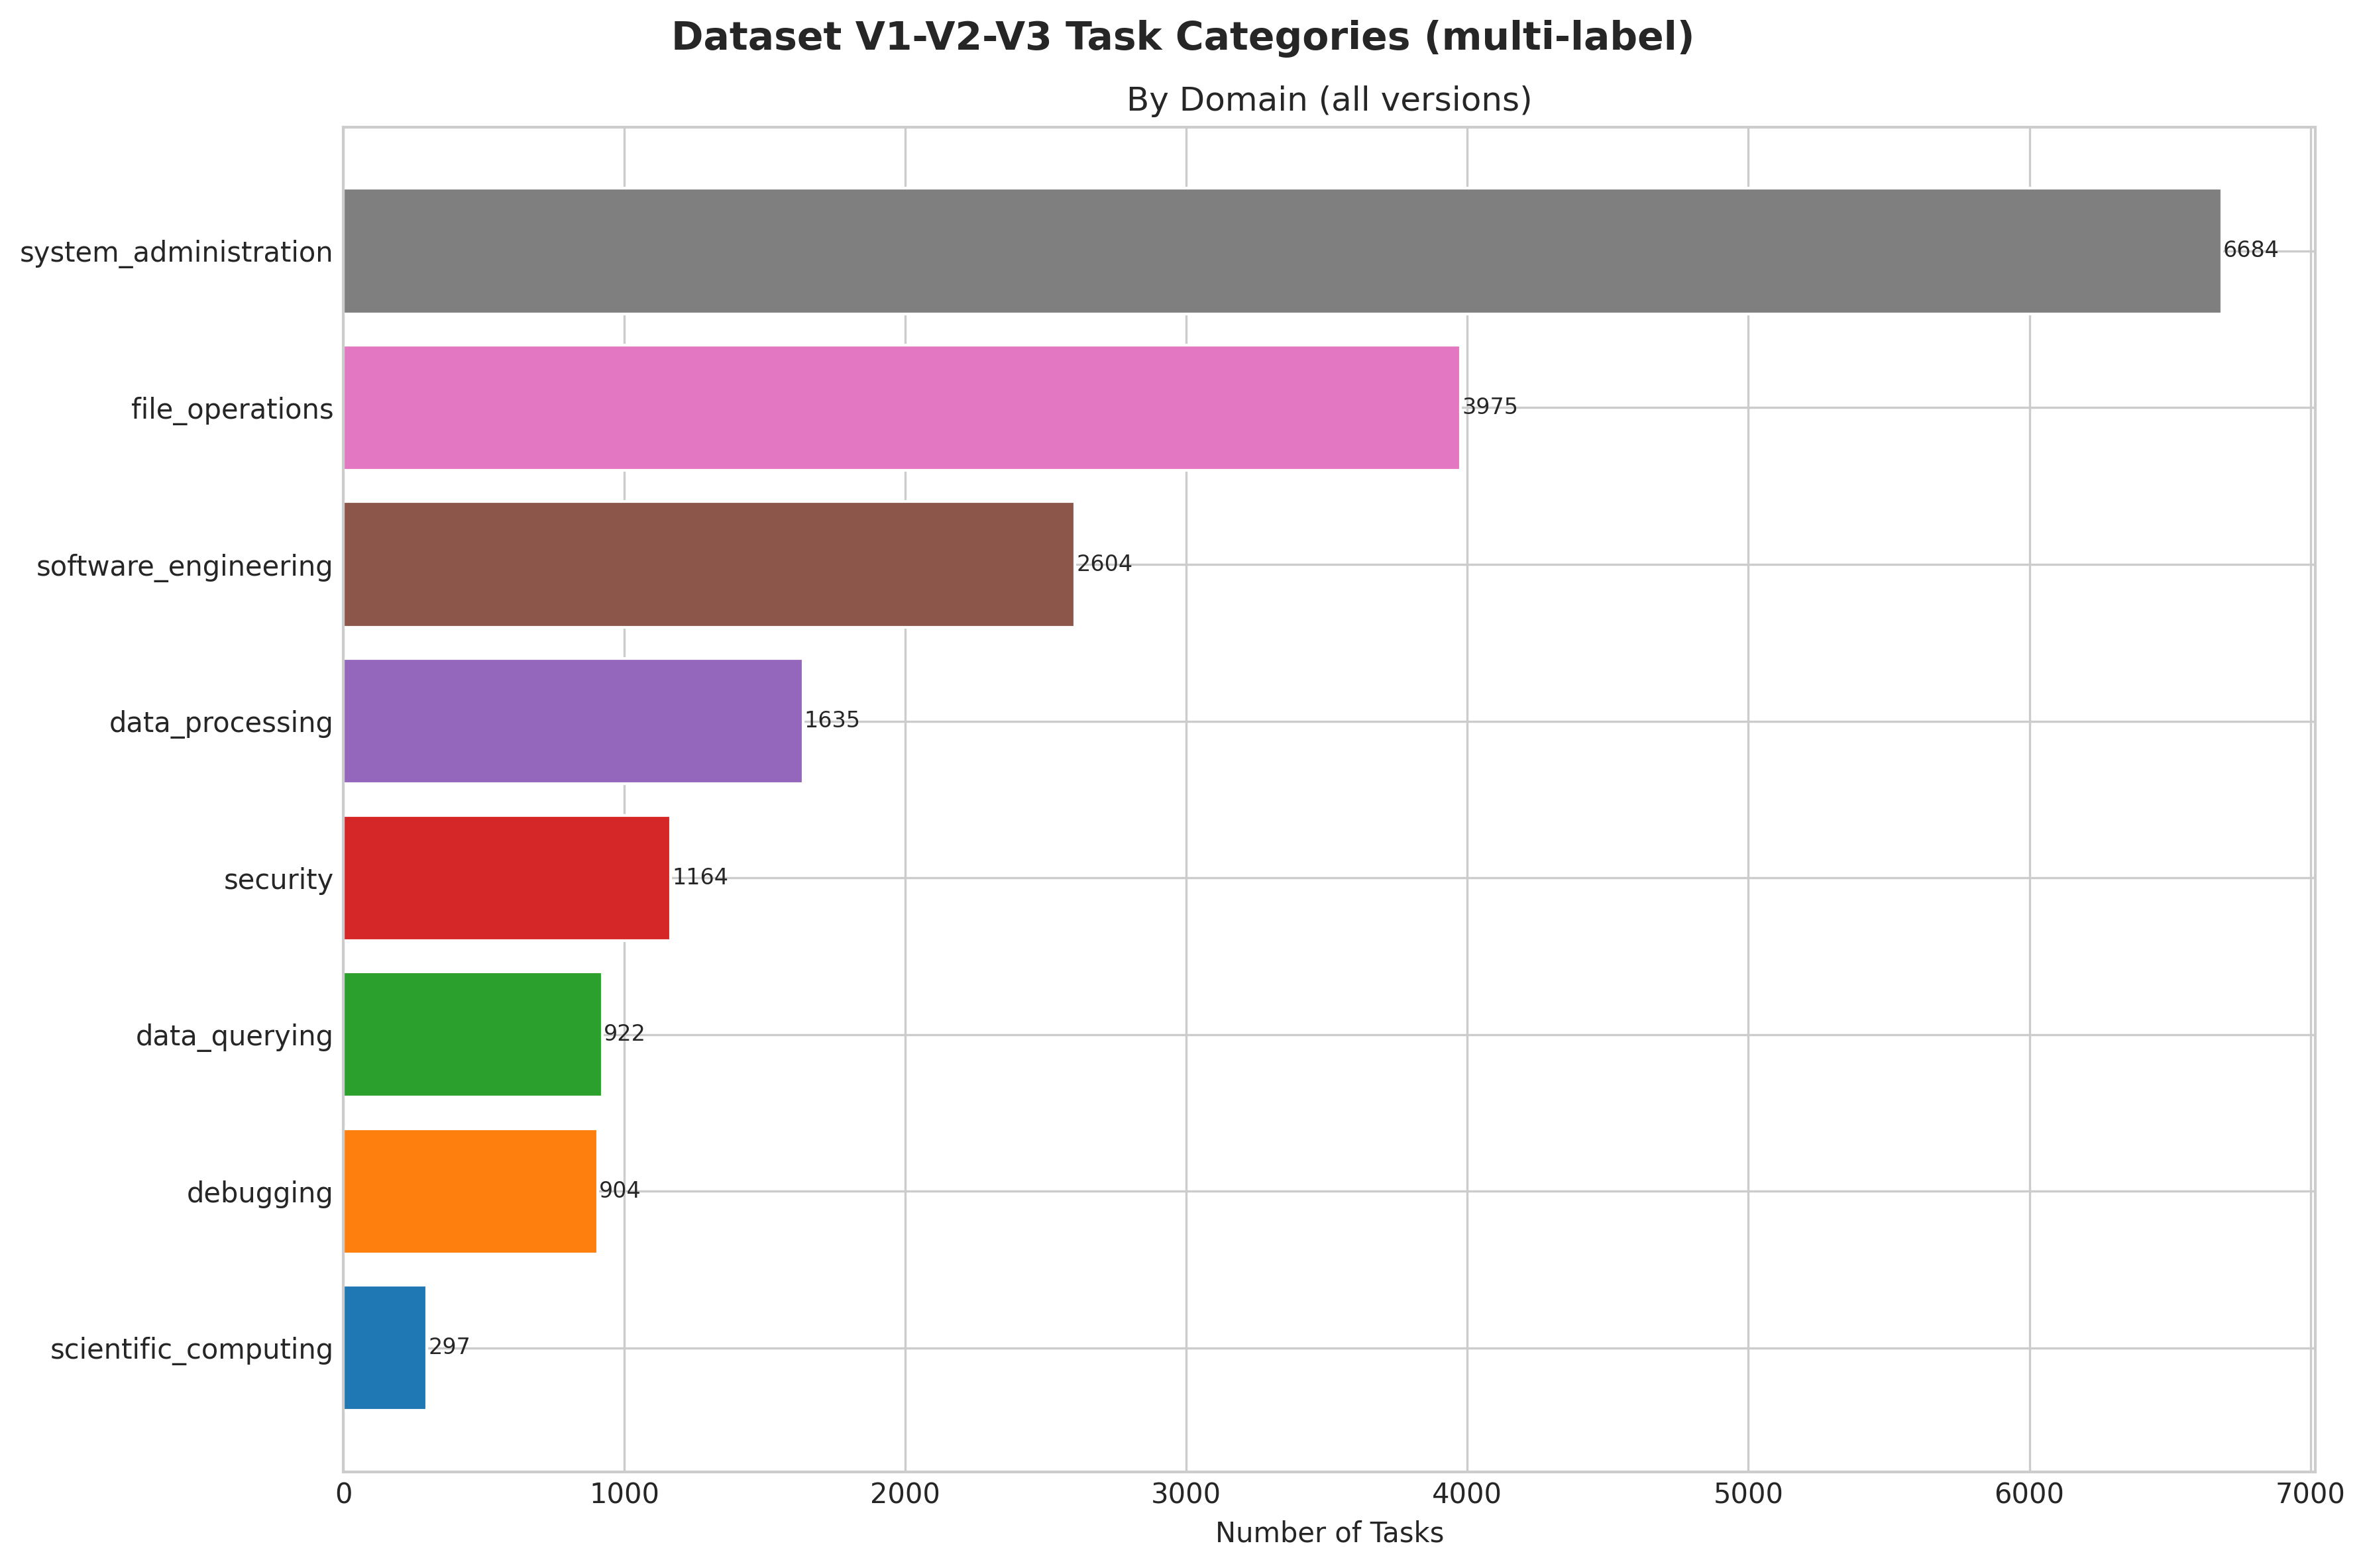


Total tasks: 18,185
Unique domains: 8
Unique categories: 64


In [74]:
domain_counts = df['domain'].value_counts().sort_values(ascending=True)

fig, axes = plt.subplots(1, 1, figsize=(12, 8))
fig.suptitle(f'Dataset {version_tag} Task Categories (multi-label)', fontsize=14, fontweight='bold')


colors = plt.cm.tab10.colors
axes.barh(domain_counts.index, domain_counts.values, color=colors[:len(domain_counts)], edgecolor='white')
axes.set_xlabel('Number of Tasks')
axes.set_title('By Domain (all versions)')
for i, v in enumerate(domain_counts.values):
    axes.text(v + 5, i, str(v), va='center', fontsize=8)


fig.savefig(f'{version_tag}_task_categories_multi-label.pdf')
plt.tight_layout()
plt.show()

print(f'\nTotal tasks: {len(df):,}')
print(f'Unique domains: {df["domain"].nunique()}')
print(f'Unique categories: {df["category"].nunique()}')

## 4. Instruction Length Distribution

In [96]:
# Compute word count and line count from description_len proxy
# (description column not stored — recompute from description_len as chars)
# We load instruction text stats fresh here
def load_instruction_stats(dataset_dirs):
    if isinstance(dataset_dirs, (str, Path)):
        dataset_dirs = [dataset_dirs]
    rows = []
    seen = set()
    for dataset_dir in dataset_dirs:
        if not dataset_dir.exists():
            continue
        version = get_version_label(dataset_dir)
        for task_dir in sorted(dataset_dir.iterdir()):
            if not task_dir.is_dir() or not task_dir.name.startswith('task_'):
                continue
            if task_dir.name in seen:
                continue
            seen.add(task_dir.name)
            instruction_path = task_dir / 'instruction.md'
            if not instruction_path.exists():
                continue
            text = instruction_path.read_text(errors='replace')
            rows.append({
                'task_id':    task_dir.name,
                'version':    version,
                'char_count': len(text),
                'word_count': len(text.split()),
                'line_count': len(text.splitlines()),
                'num_steps':  len(re.findall(r'^\s*\d+\.', text, re.MULTILINE)),
                'has_code_block': int(bool(re.search(r'```', text))),
            })
    return pd.DataFrame(rows)

df_inst = load_instruction_stats(DATASET_DIRS)
print(f'Loaded {len(df_inst):,} instruction files')
print(df_inst[['char_count', 'word_count', 'line_count', 'num_steps']].describe().round(1).to_string())

Loaded 18,185 instruction files
       char_count  word_count  line_count  num_steps
count     18185.0     18185.0     18185.0    18185.0
mean        619.9        99.4         2.6        0.0
std         183.3        29.7         1.2        0.0
min         100.0        18.0         1.0        0.0
25%         523.0        84.0         1.0        0.0
50%         628.0       101.0         3.0        0.0
75%         731.0       118.0         3.0        0.0
max        1855.0       291.0         9.0        0.0


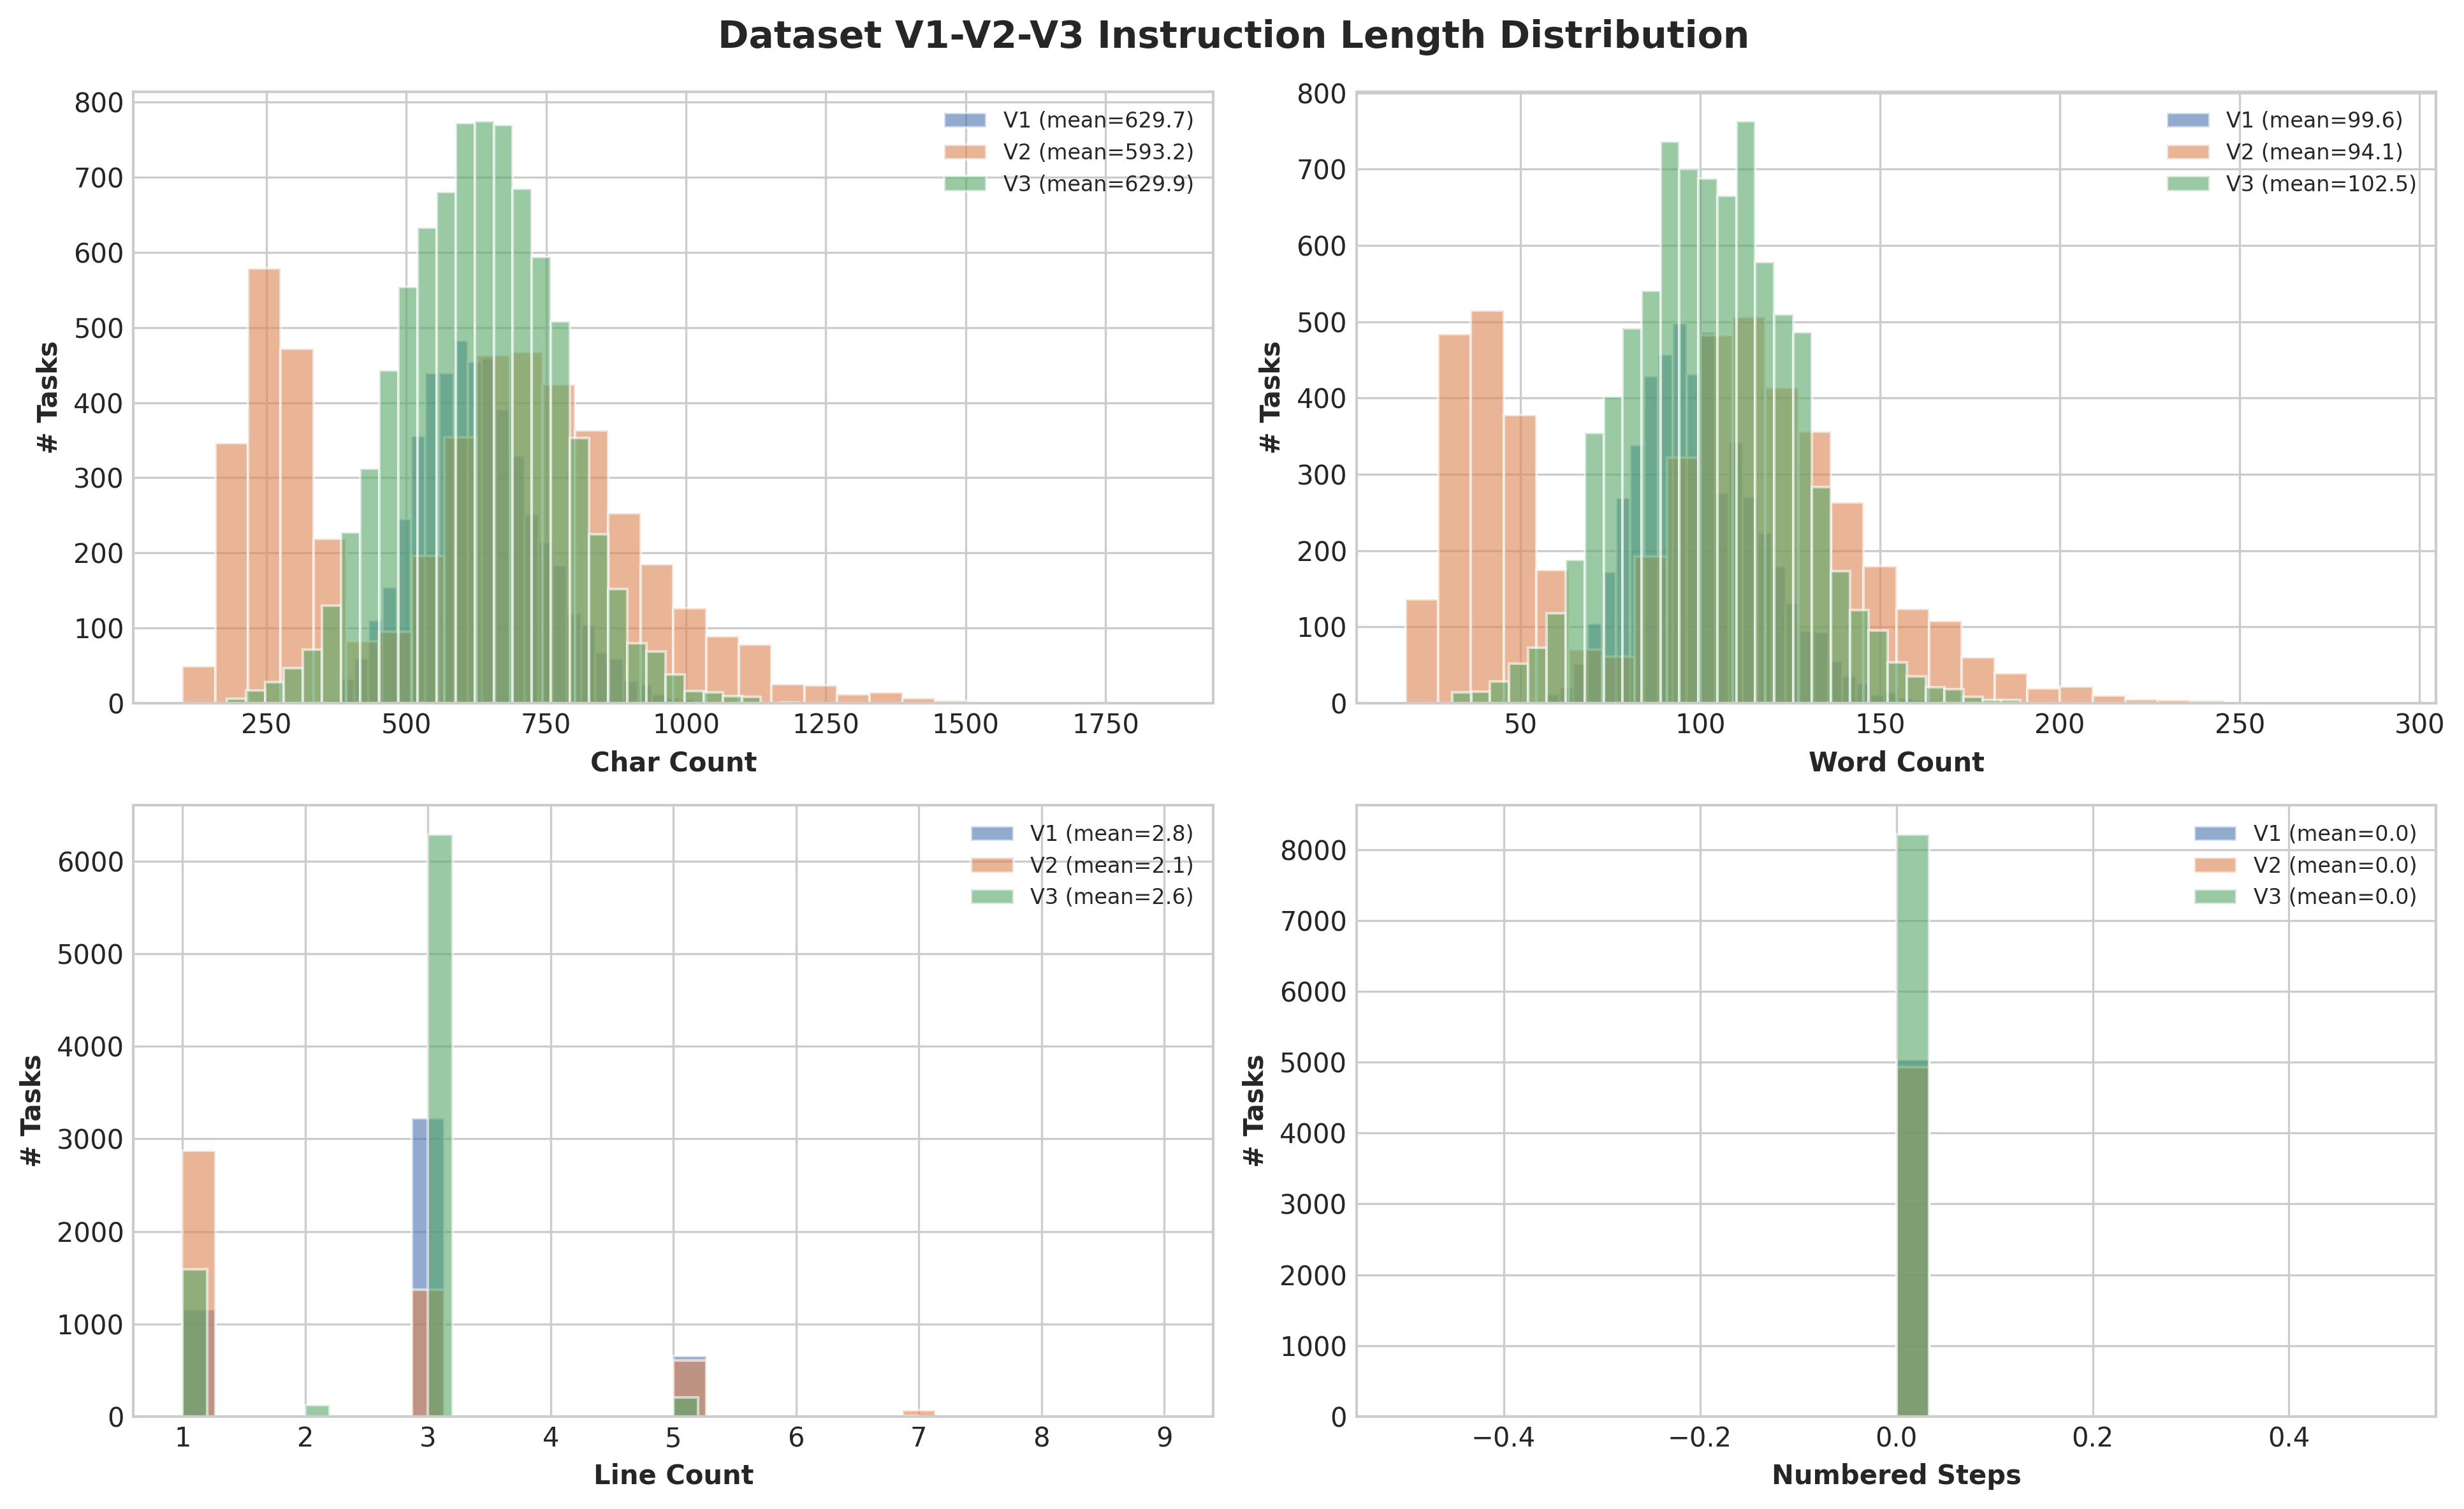

         char_count  word_count  line_count  num_steps
version                                               
V1            629.7        99.6         2.8        0.0
V2            593.2        94.1         2.1        0.0
V3            629.9       102.5         2.6        0.0


In [97]:
metrics_inst = [
    ('char_count', 'Char Count'),
    ('word_count', 'Word Count'),
    ('line_count', 'Line Count'),
    ('num_steps',  'Numbered Steps'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle(f'Dataset {version_tag} Instruction Length Distribution', fontsize=14, fontweight='bold')

version_order = ['V1', 'V2', 'V3']
colors_v = {'V1': '#4C72B0', 'V2': '#DD8452', 'V3': '#55A868'}

for ax, (col, label) in zip(axes.flat, metrics_inst):
    for v in version_order:
        sub = df_inst[df_inst['version'] == v][col]
        if sub.empty:
            continue
        ax.hist(sub, bins=30, alpha=0.6, label=f'{v} (mean={sub.mean():.1f})',
                color=colors_v[v], edgecolor='white')
    ax.set_xlabel(label, fontweight='bold')
    ax.set_ylabel('# Tasks', fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(f'{version_tag}_instruction_length_dist.pdf', bbox_inches='tight')
plt.show()

print(df_inst.groupby('version')[['char_count', 'word_count', 'line_count', 'num_steps']]
      .mean().round(1).to_string())

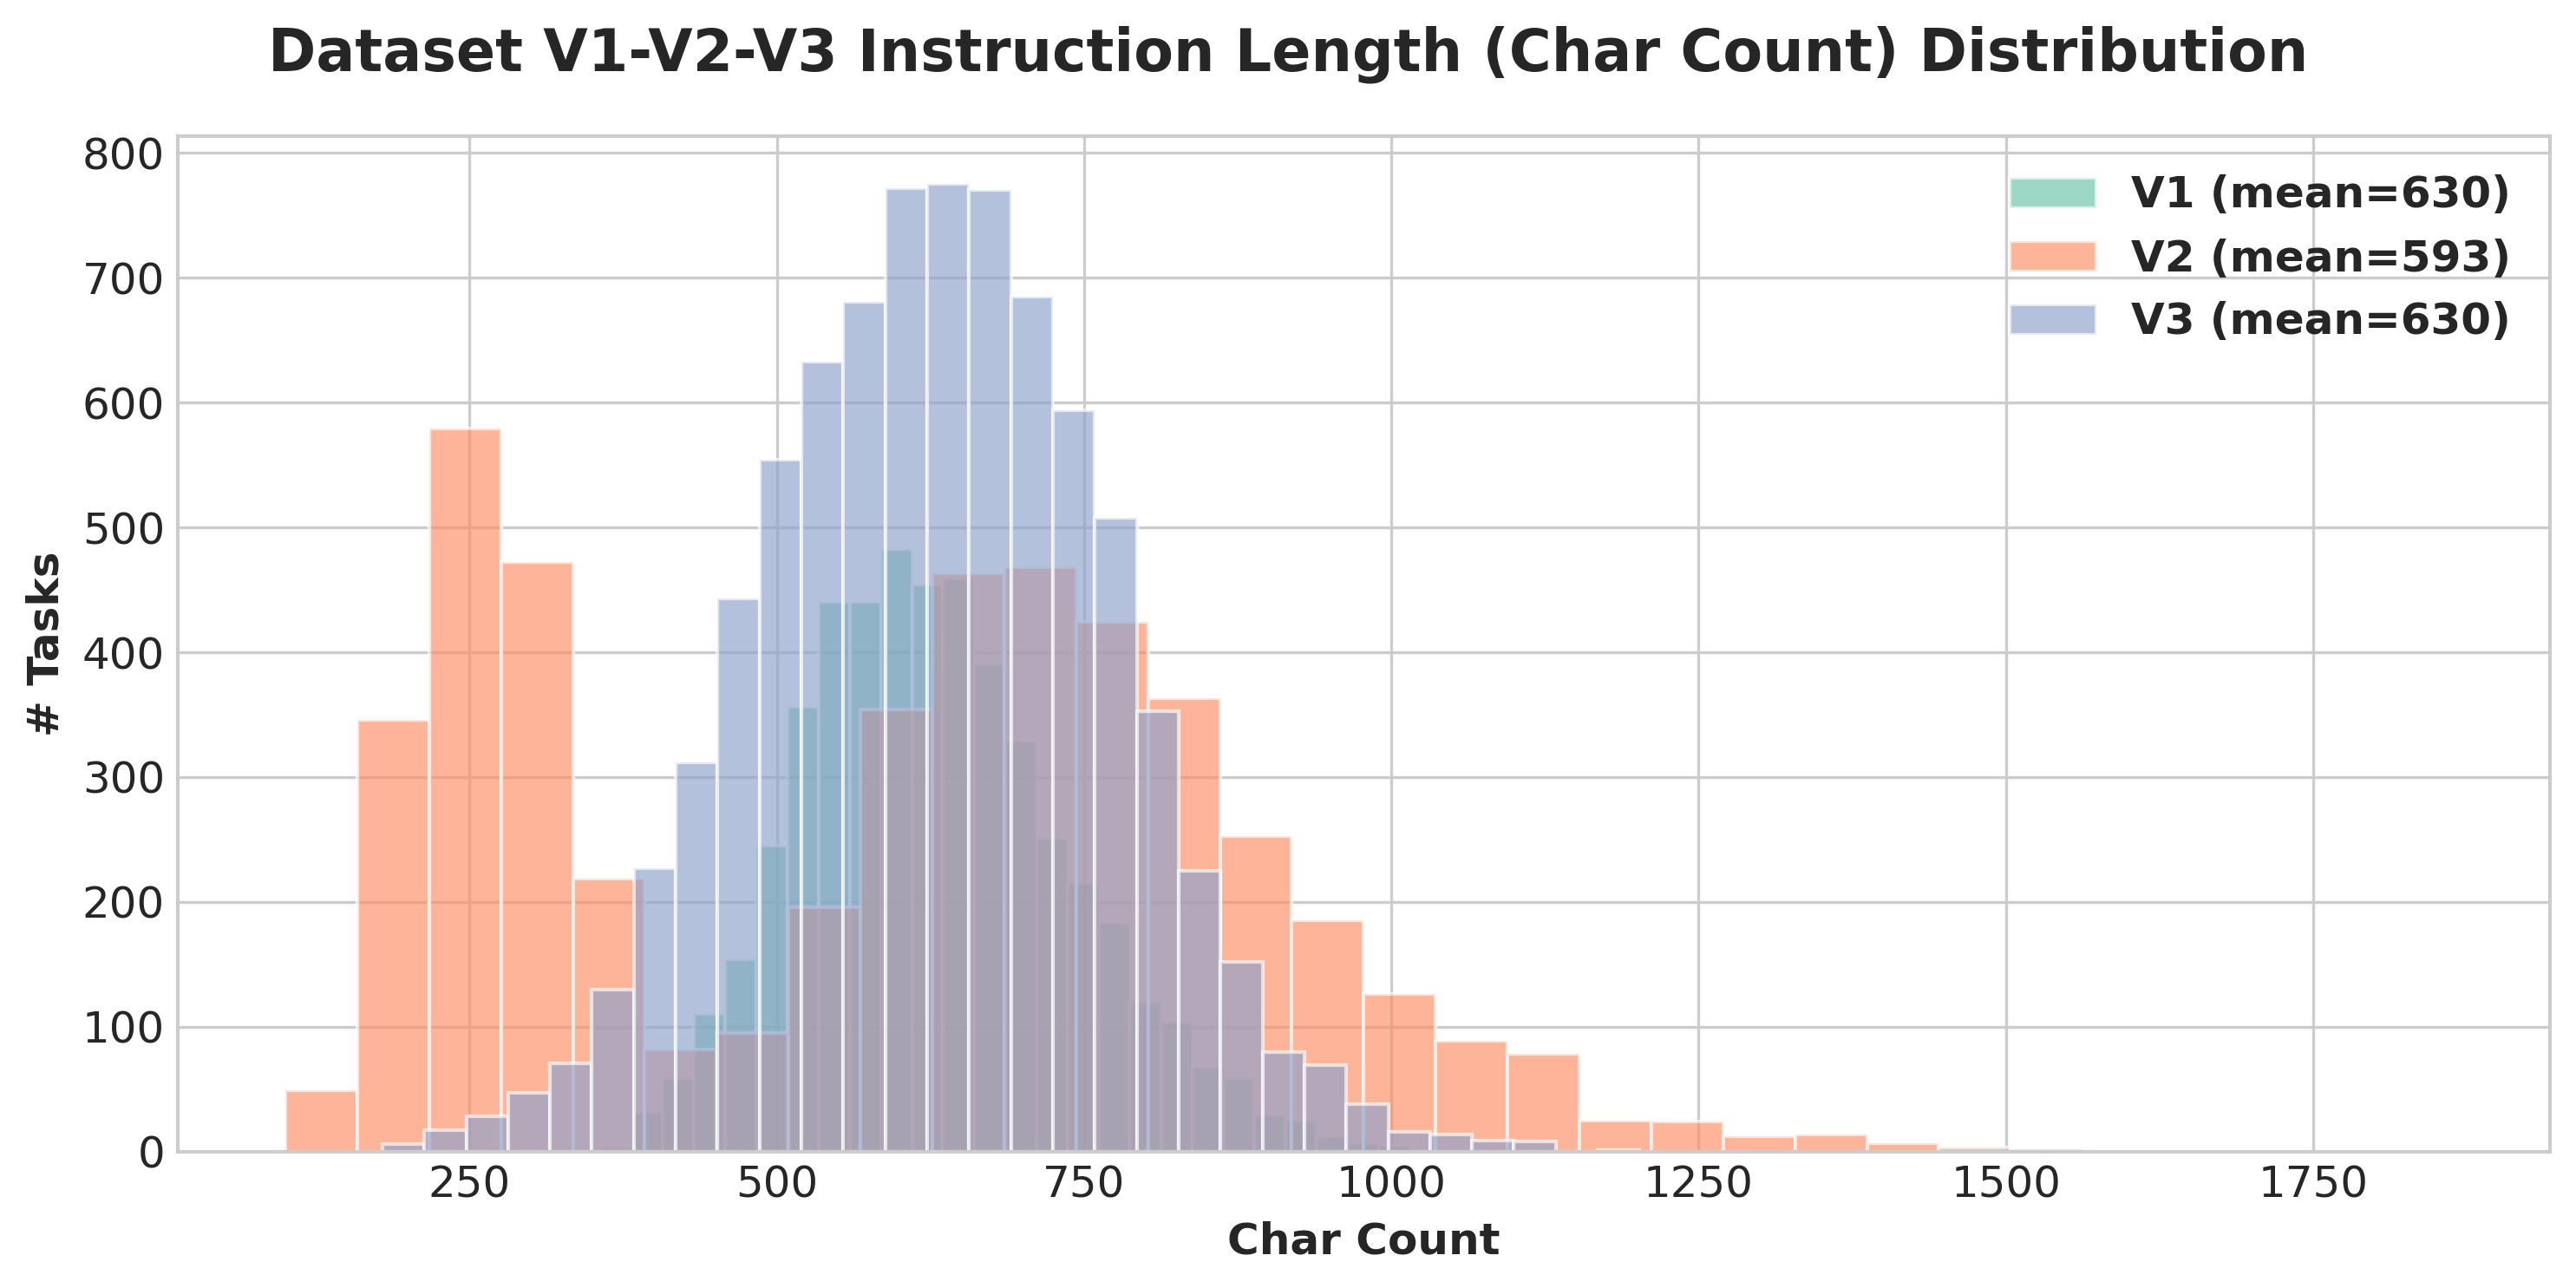

In [ ]:
set2 = plt.cm.Set2.colors
version_order = ['V1', 'V2', 'V3']
colors_set2 = {v: set2[i] for i, v in enumerate(version_order)}

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle(f'{version_tag} Instruction Length (Char Count) Distribution', fontsize=16, fontweight='bold')

for v in version_order:
    sub = df_inst[df_inst['version'] == v]['char_count']
    if sub.empty:
        continue
    ax.hist(sub, bins=30, alpha=0.65, label=f'{v} (mean={sub.mean():.0f})',
            color=colors_set2[v], edgecolor='white')

ax.set_xlabel('Char Count', fontsize=12, fontweight='bold')
ax.set_ylabel('# Tasks', fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=12)
legend = ax.legend(fontsize=12)
for text in legend.get_texts():
    text.set_fontweight('bold')

plt.tight_layout()
fig.savefig(f'{version_tag}_instruction_char_count_dist.pdf', bbox_inches='tight')
plt.show()

## 5. Assertion Quality Analysis

In [105]:
_SEMANTIC_PATTERNS = {
    'process_output':  re.compile(r'\bassert\b[^\n]*(stdout|stderr|returncode|subprocess|capture_output)', re.I),
    'file_existence':  re.compile(r'\bassert\b[^\n]*(exists\(\)|is_file\(\)|is_dir\(\)|os\.path)', re.I),
    'file_content':    re.compile(r'\bassert\b[^\n]*(\.read\b|open\(|read_text|content\b)', re.I),
    'string_match':    re.compile(r'\bassert\b[^\n]*(==\s*["\']|in\s+["\']|startswith|endswith|strip\(\))', re.I),
    'numeric':         re.compile(r'\bassert\b[^\n]*([<>]=?|==)\s*\d', re.I),
    'boolean':         re.compile(r'\bassert\b[^\n]*(True|False|is None|is not None)', re.I),
    'permission':      re.compile(r'\bassert\b[^\n]*(chmod|stat\b|mode|permission|owner)', re.I),
}

def classify_assert_line(line):
    for label, pat in _SEMANTIC_PATTERNS.items():
        if pat.search(line):
            return label
    return 'other'

def load_assertion_stats(dataset_dirs):
    if isinstance(dataset_dirs, (str, Path)):
        dataset_dirs = [dataset_dirs]
    rows = []
    seen = set()
    for dataset_dir in dataset_dirs:
        if not dataset_dir.exists():
            continue
        version = get_version_label(dataset_dir)
        for task_dir in sorted(dataset_dir.iterdir()):
            if not task_dir.is_dir() or not task_dir.name.startswith('task_'):
                continue
            if task_dir.name in seen:
                continue
            seen.add(task_dir.name)
            test_path = task_dir / 'tests' / 'test_final_state.py'
            if not test_path.exists():
                continue
            test_code = test_path.read_text(errors='replace')
            assert_lines = re.findall(r'\bassert\b[^\n]*', test_code)
            num_asserts = len(assert_lines)
            type_counts = {label: 0 for label in _SEMANTIC_PATTERNS}
            type_counts['other'] = 0
            for line in assert_lines:
                type_counts[classify_assert_line(line)] += 1
            rows.append({'task_id': task_dir.name, 'version': version,
                         'num_asserts': num_asserts, **type_counts})
    return pd.DataFrame(rows)

df_assert = load_assertion_stats(DATASET_DIRS)
print(f'Loaded {len(df_assert):,} tasks')
print(df_assert.groupby('version')[list(_SEMANTIC_PATTERNS.keys()) + ['other', 'num_asserts']].mean().round(2).to_string())

Loaded 18,185 tasks
         process_output  file_existence  file_content  string_match  numeric  boolean  permission  other  num_asserts
version                                                                                                              
V1                 5.66            4.98          3.70          0.96     3.37     0.60        0.13   4.89        24.29
V2                 4.30            4.40          5.76          1.81     3.60     0.58        0.38   4.90        25.74
V3                 2.76            4.91          1.69          1.40     3.13     1.55        0.18  12.04        27.65


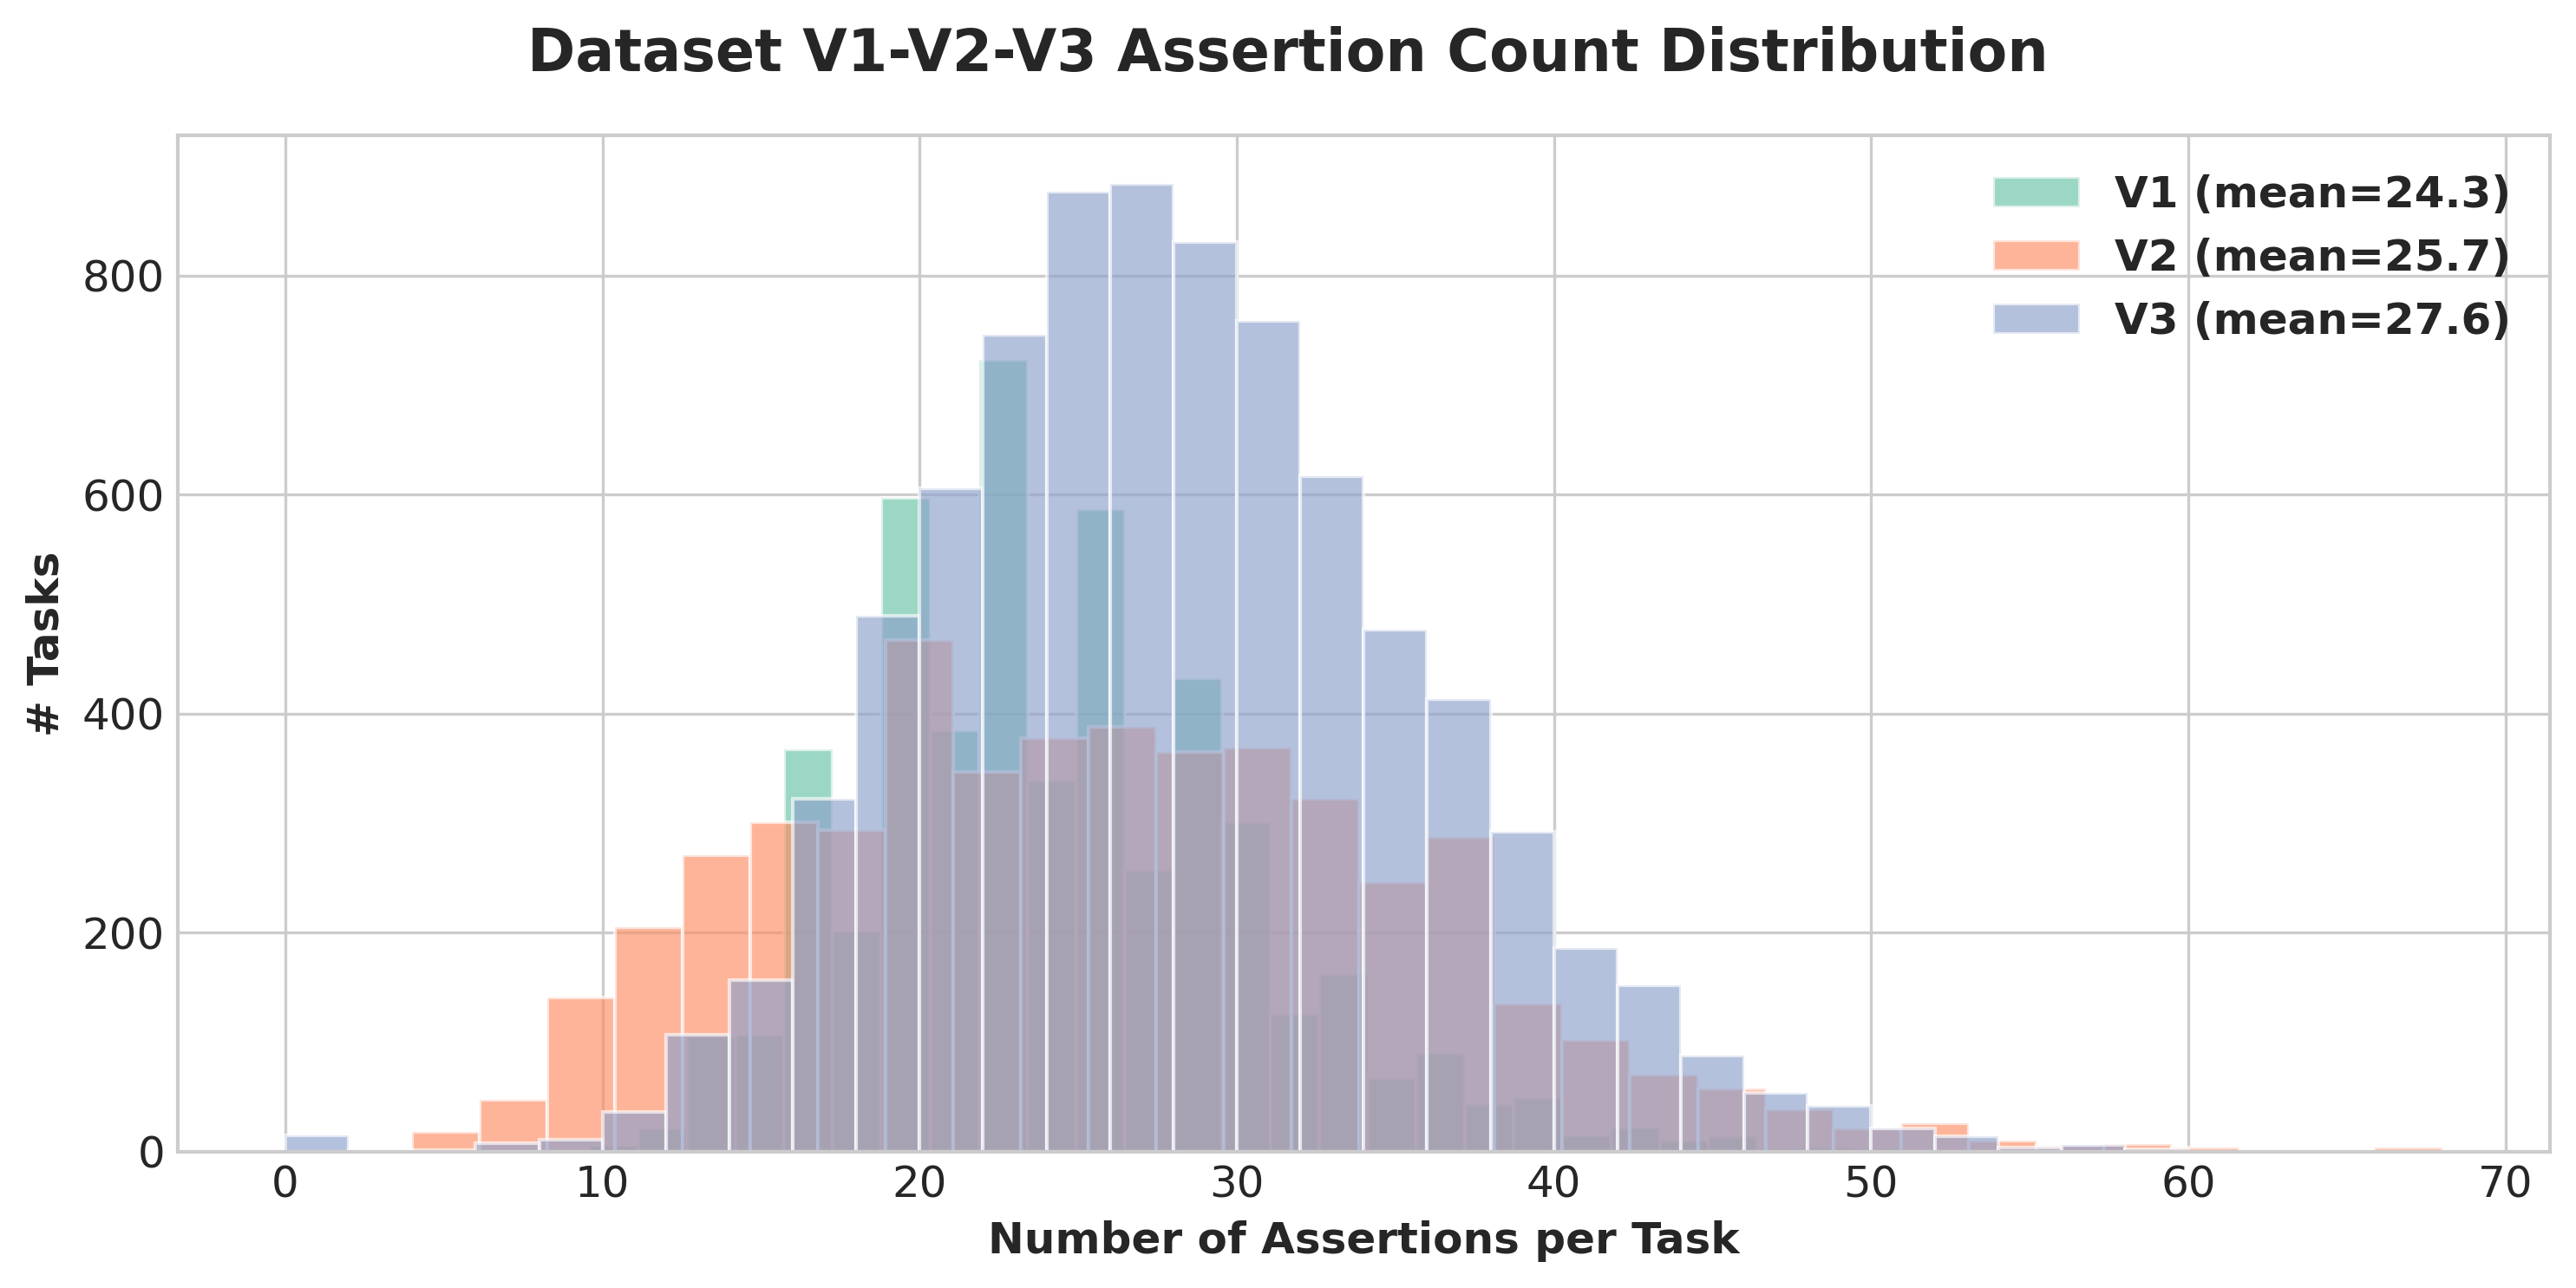

In [106]:
# 5.1 Assertion Count Distribution per version
set2 = plt.cm.Set2.colors
version_order = ['V1', 'V2', 'V3']
colors_set2 = {v: set2[i] for i, v in enumerate(version_order)}

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle(f'Dataset {version_tag} Assertion Count Distribution', fontsize=16, fontweight='bold')

for v in version_order:
    sub = df_assert[df_assert['version'] == v]['num_asserts']
    if sub.empty:
        continue
    ax.hist(sub, bins=30, alpha=0.65, label=f'{v} (mean={sub.mean():.1f})',
            color=colors_set2[v], edgecolor='white')

ax.set_xlabel('Number of Assertions per Task', fontsize=12, fontweight='bold')
ax.set_ylabel('# Tasks', fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=12)
legend = ax.legend(fontsize=12)
for text in legend.get_texts():
    text.set_fontweight('bold')

plt.tight_layout()
fig.savefig(f'{version_tag}_assertion_count_dist.pdf', bbox_inches='tight')
plt.show()

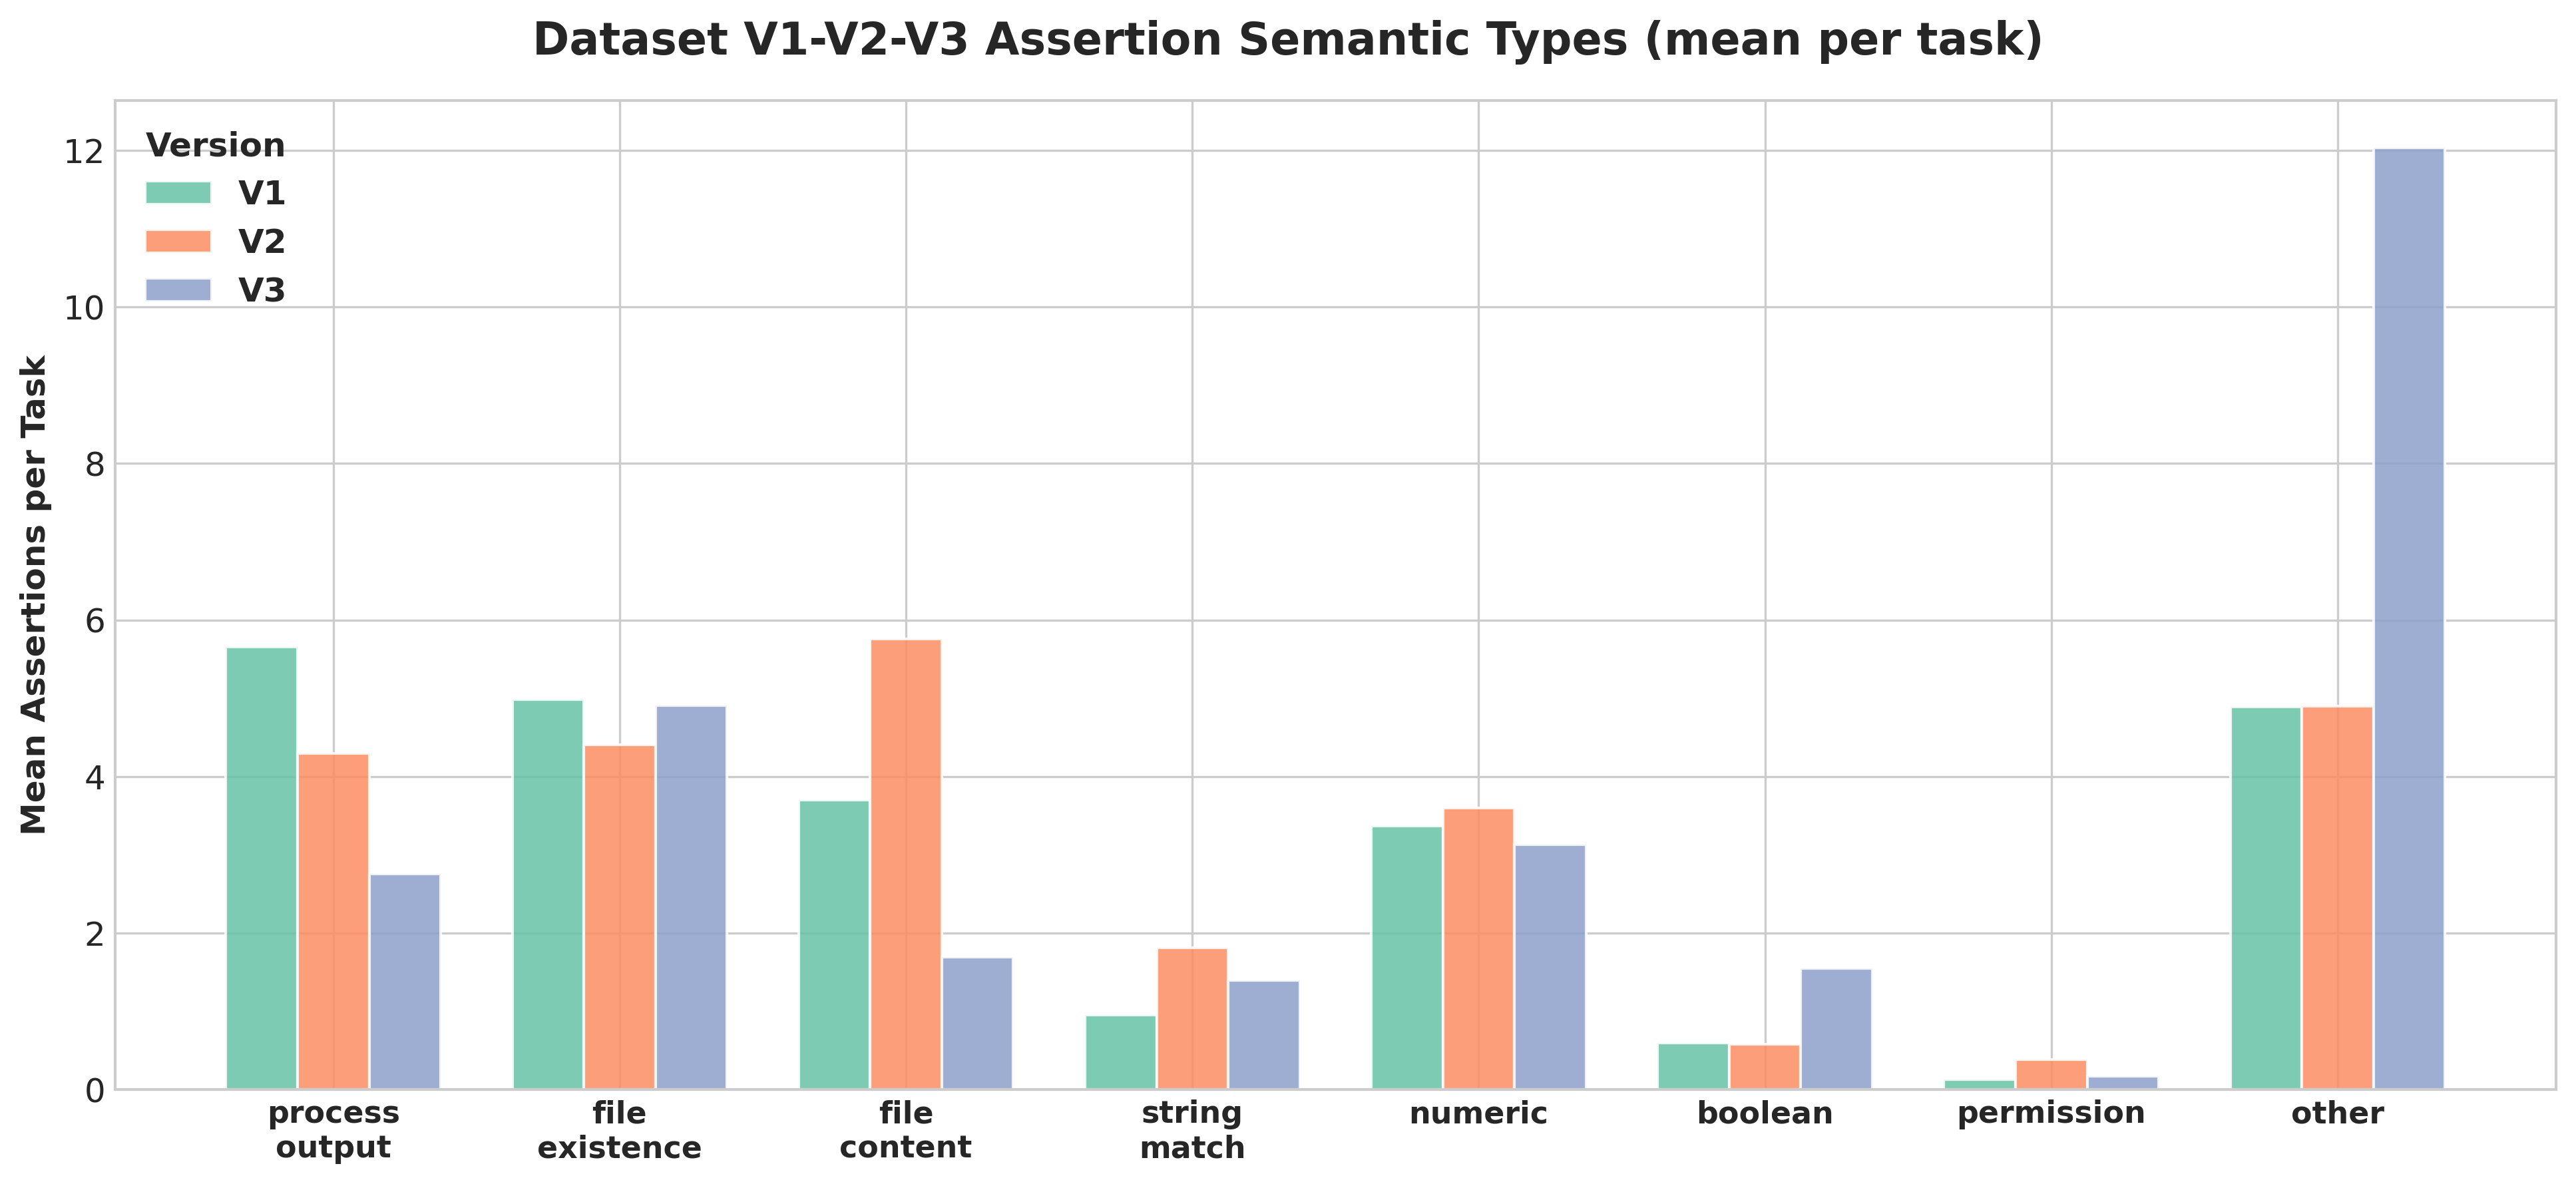

In [107]:
# 5.2 Assertion Semantic Type Breakdown per version
semantic_cols = list(_SEMANTIC_PATTERNS.keys()) + ['other']

# Mean count per task, per version
means = df_assert.groupby('version')[semantic_cols].mean().reindex(version_order)

x = np.arange(len(semantic_cols))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle(f'Dataset {version_tag} Assertion Semantic Types (mean per task)', fontsize=16, fontweight='bold')

for i, v in enumerate(version_order):
    ax.bar(x + i * width, means.loc[v], width, label=v,
           color=colors_set2[v], edgecolor='white', alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels([c.replace('_', '\n') for c in semantic_cols], fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Assertions per Task', fontsize=12, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)

legend = ax.legend(title='Version', fontsize=12)
legend.get_title().set_fontweight('bold')
legend.get_title().set_fontsize(12)
for text in legend.get_texts():
    text.set_fontweight('bold')

plt.tight_layout()
fig.savefig(f'{version_tag}_assertion_semantic_types.pdf', bbox_inches='tight')
plt.show()

## 6. Task Dependency & Tool Calling Complexity

In [108]:
_CLI_TOOLS = {
    'grep', 'awk', 'sed', 'find', 'xargs', 'sort', 'uniq', 'cut', 'tr', 'wc',
    'cat', 'head', 'tail', 'diff', 'patch', 'tee', 'echo', 'printf',
    'curl', 'wget', 'ssh', 'scp', 'rsync', 'nc', 'netcat',
    'git', 'make', 'docker', 'pip', 'apt', 'apt-get', 'yum', 'dnf',
    'python', 'python3', 'bash', 'sh', 'chmod', 'chown', 'ln', 'cp', 'mv', 'rm',
    'tar', 'gzip', 'zip', 'unzip', 'gpg', 'openssl', 'jq', 'yq',
    'sqlite3', 'psql', 'mysql', 'cron', 'crontab', 'systemctl', 'service',
    'ps', 'kill', 'top', 'df', 'du', 'lsof', 'netstat', 'ss', 'ping', 'dig',
    'useradd', 'usermod', 'groupadd', 'passwd', 'su', 'sudo',
}

_PIPE_PAT    = re.compile(r'\|')
_REDIRECT_PAT = re.compile(r'>>?|<')
_AND_OR_PAT  = re.compile(r'&&|\|\|')
_SUBSHELL_PAT = re.compile(r'\$\(|\`')

def load_tool_complexity(dataset_dirs):
    if isinstance(dataset_dirs, (str, Path)):
        dataset_dirs = [dataset_dirs]
    rows = []
    seen = set()
    for dataset_dir in dataset_dirs:
        if not dataset_dir.exists():
            continue
        version = get_version_label(dataset_dir)
        for task_dir in sorted(dataset_dir.iterdir()):
            if not task_dir.is_dir() or not task_dir.name.startswith('task_'):
                continue
            if task_dir.name in seen:
                continue
            seen.add(task_dir.name)
            instruction_path = task_dir / 'instruction.md'
            if not instruction_path.exists():
                continue
            text = instruction_path.read_text(errors='replace').lower()
            words = set(re.findall(r'\b\w+\b', text))
            tools_mentioned = words & _CLI_TOOLS
            rows.append({
                'task_id':        task_dir.name,
                'version':        version,
                'num_tools':      len(tools_mentioned),
                'tools':          tools_mentioned,
                'pipe_count':     len(_PIPE_PAT.findall(text)),
                'redirect_count': len(_REDIRECT_PAT.findall(text)),
                'and_or_count':   len(_AND_OR_PAT.findall(text)),
                'subshell_count': len(_SUBSHELL_PAT.findall(text)),
                'chain_score':    (len(_PIPE_PAT.findall(text)) +
                                   len(_AND_OR_PAT.findall(text)) +
                                   len(_SUBSHELL_PAT.findall(text))),
            })
    return pd.DataFrame(rows)

df_tool = load_tool_complexity(DATASET_DIRS)
print(f'Loaded {len(df_tool):,} tasks')
print(df_tool.groupby('version')[['num_tools', 'pipe_count', 'redirect_count', 'and_or_count', 'subshell_count', 'chain_score']]
      .mean().round(2).to_string())

Loaded 18,185 tasks
         num_tools  pipe_count  redirect_count  and_or_count  subshell_count  chain_score
version                                                                                  
V1            1.58        0.01            0.02          0.01            1.49         1.51
V2            1.52        0.01            0.04          0.01            3.06         3.09
V3            1.40        0.01            0.09          0.00            1.43         1.44


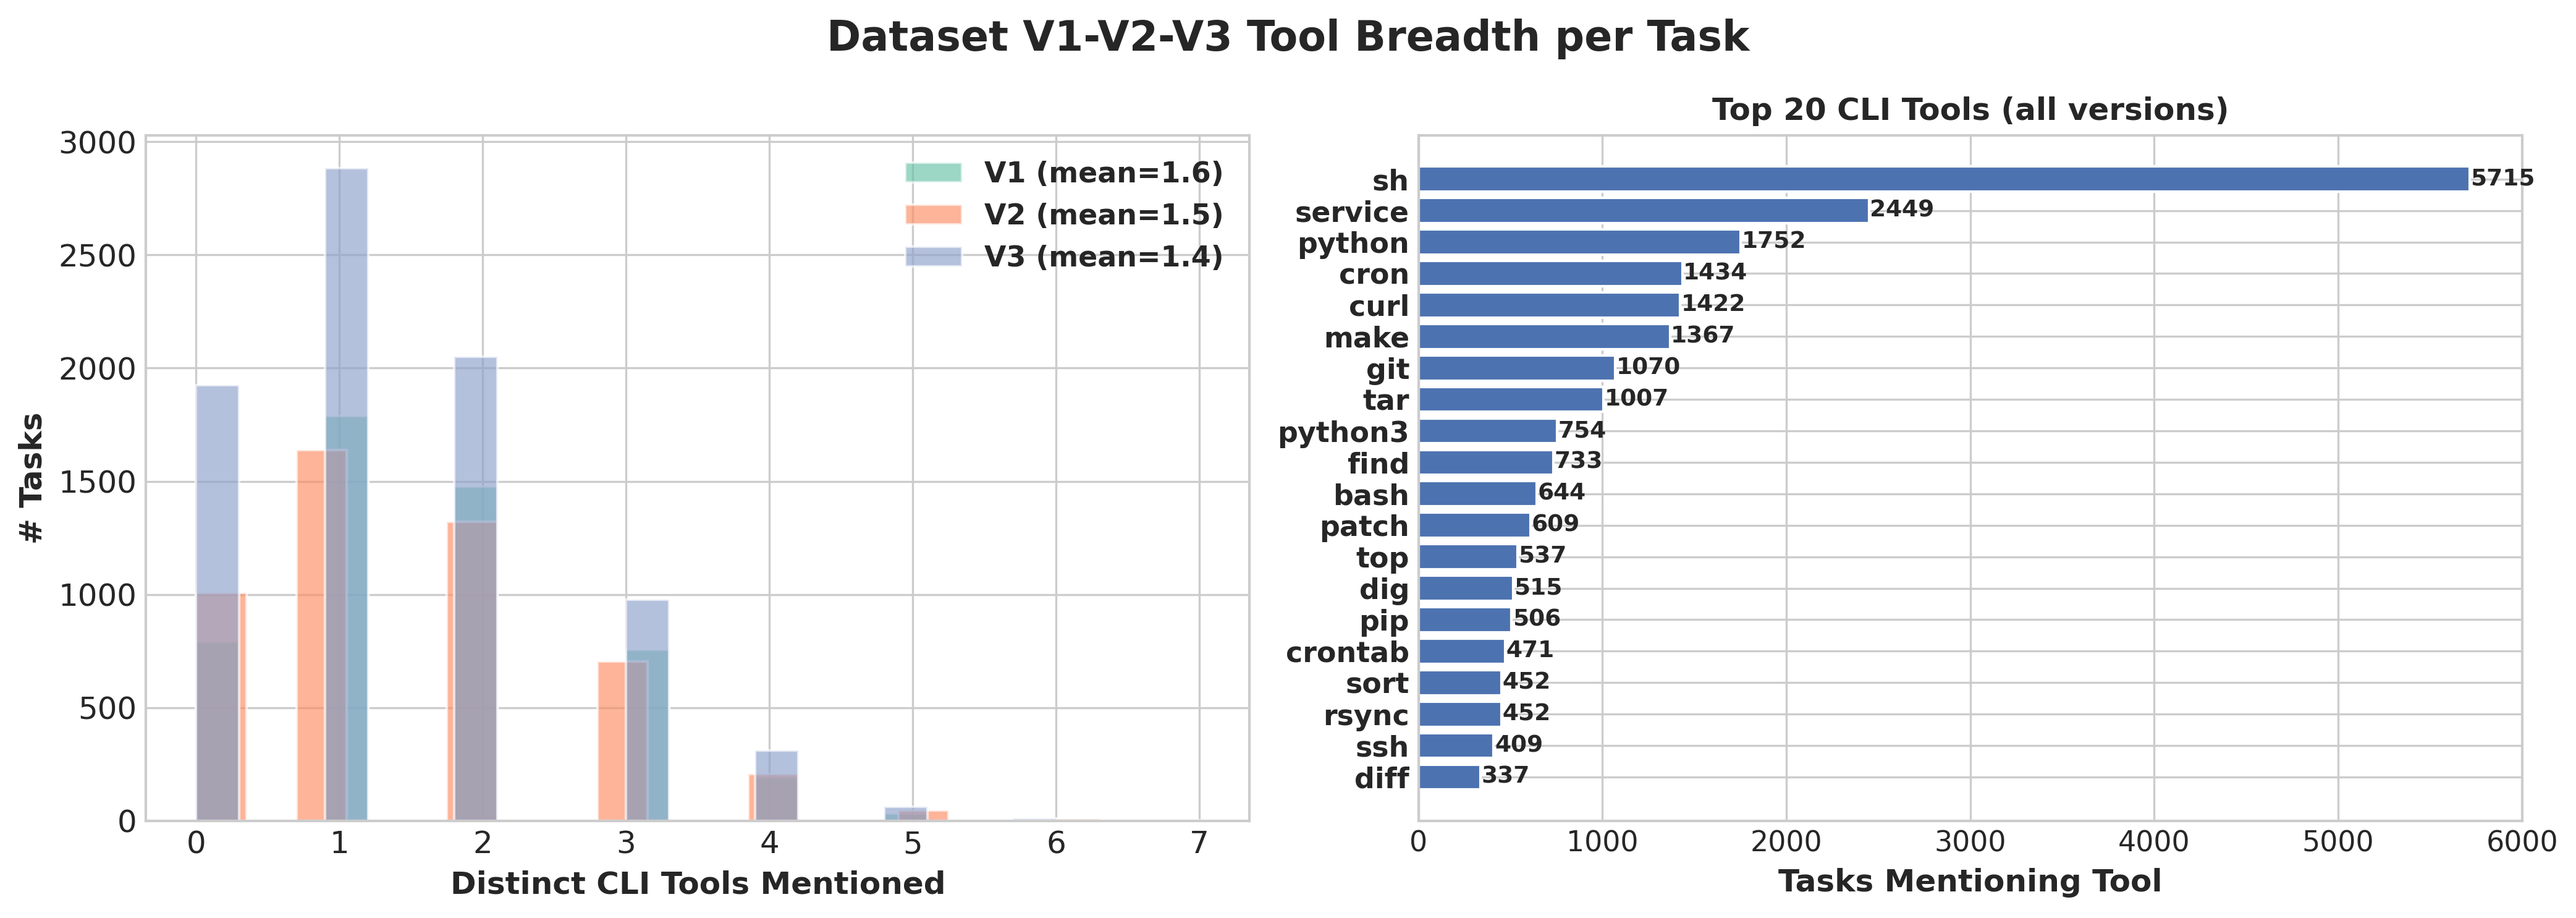

In [109]:
# 6.1 Tool breadth: distinct CLI tools mentioned per task
set2 = plt.cm.Set2.colors
version_order = ['V1', 'V2', 'V3']
colors_set2 = {v: set2[i] for i, v in enumerate(version_order)}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Dataset {version_tag} Tool Breadth per Task', fontsize=16, fontweight='bold')

# Left: distribution
for v in version_order:
    sub = df_tool[df_tool['version'] == v]['num_tools']
    axes[0].hist(sub, bins=20, alpha=0.65, label=f'{v} (mean={sub.mean():.1f})',
                 color=colors_set2[v], edgecolor='white')
axes[0].set_xlabel('Distinct CLI Tools Mentioned', fontsize=12, fontweight='bold')
axes[0].set_ylabel('# Tasks', fontsize=12, fontweight='bold')
axes[0].tick_params(labelsize=12)
leg = axes[0].legend(fontsize=11)
for t in leg.get_texts(): t.set_fontweight('bold')

# Right: top-20 tools across all tasks
from collections import Counter
all_tools = Counter(t for tools in df_tool['tools'] for t in tools)
top_tools = pd.Series(dict(all_tools.most_common(20))).sort_values()
axes[1].barh(top_tools.index, top_tools.values, color='#4C72B0', edgecolor='white')
axes[1].set_xlabel('Tasks Mentioning Tool', fontsize=12, fontweight='bold')
axes[1].set_title('Top 20 CLI Tools (all versions)', fontsize=12, fontweight='bold')
axes[1].tick_params(labelsize=11)
for label in axes[1].get_yticklabels():
    label.set_fontweight('bold')
for i, v in enumerate(top_tools.values):
    axes[1].text(v + 5, i, str(v), va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
fig.savefig(f'{version_tag}_tool_breadth.pdf', bbox_inches='tight')
plt.show()

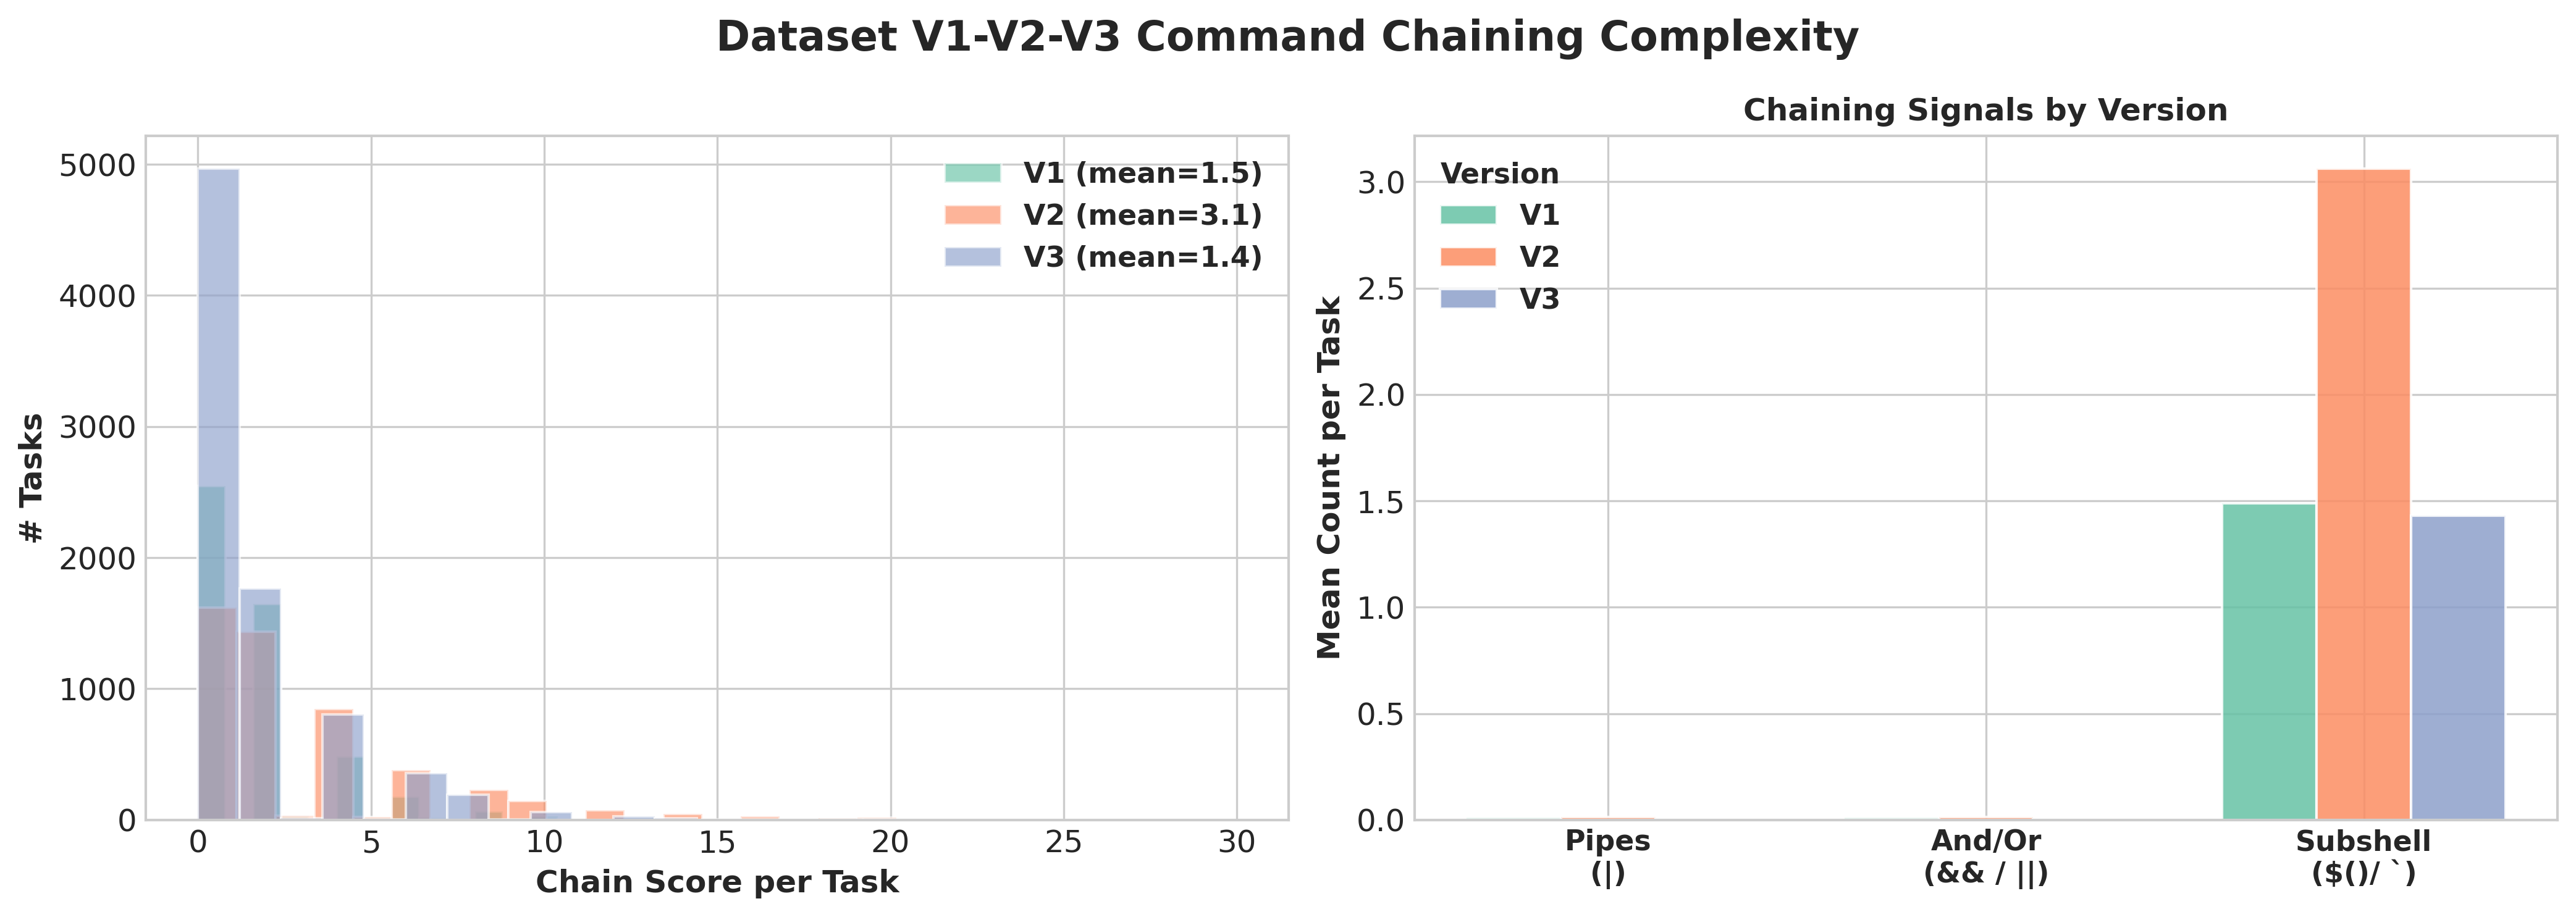

In [110]:
# 6.2 Command chaining complexity
chain_metrics = [
    ('pipe_count',     'Pipe Count (|)'),
    ('and_or_count',   'And/Or Count (&& / ||)'),
    ('subshell_count', 'Subshell Count ($( ) / `)'),
    ('chain_score',    'Chain Score (sum)'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Dataset {version_tag} Command Chaining Complexity', fontsize=16, fontweight='bold')

# Left: chain score distribution per version
for v in version_order:
    sub = df_tool[df_tool['version'] == v]['chain_score']
    axes[0].hist(sub, bins=25, alpha=0.65, label=f'{v} (mean={sub.mean():.1f})',
                 color=colors_set2[v], edgecolor='white')
axes[0].set_xlabel('Chain Score per Task', fontsize=12, fontweight='bold')
axes[0].set_ylabel('# Tasks', fontsize=12, fontweight='bold')
axes[0].tick_params(labelsize=12)
leg = axes[0].legend(fontsize=11)
for t in leg.get_texts(): t.set_fontweight('bold')

# Right: grouped bar — mean of each chaining signal per version
chain_cols = ['pipe_count', 'and_or_count', 'subshell_count']
means_chain = df_tool.groupby('version')[chain_cols].mean().reindex(version_order)
x = np.arange(len(chain_cols))
width = 0.25
for i, v in enumerate(version_order):
    axes[1].bar(x + i * width, means_chain.loc[v], width, label=v,
                color=colors_set2[v], edgecolor='white', alpha=0.85)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(['Pipes\n(|)', 'And/Or\n(&& / ||)', 'Subshell\n($()/ `)'],
                         fontsize=11, fontweight='bold')
axes[1].set_ylabel('Mean Count per Task', fontsize=12, fontweight='bold')
axes[1].set_title('Chaining Signals by Version', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='y', labelsize=12)
leg2 = axes[1].legend(title='Version', fontsize=11)
leg2.get_title().set_fontweight('bold')
leg2.get_title().set_fontsize(11)
for t in leg2.get_texts(): t.set_fontweight('bold')

plt.tight_layout()
fig.savefig(f'{version_tag}_chain_complexity.pdf', bbox_inches='tight')
plt.show()